In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
import pandas as pd

train = pd.read_csv(
    r"C:\Users\Anish kumar tiwari\Downloads\rossmann-store-sales\train.csv",
    low_memory=False
)

test = pd.read_csv(
    r"C:\Users\Anish kumar tiwari\Downloads\rossmann-store-sales\test.csv",
    low_memory=False
)

store = pd.read_csv(
    r"C:\Users\Anish kumar tiwari\Downloads\rossmann-store-sales\store.csv",
    low_memory=False
)

sample = pd.read_csv(
    r"C:\Users\Anish kumar tiwari\Downloads\rossmann-store-sales\sample_submission.csv",
    low_memory=False
)

print("Train:", train.shape)
print("Test:", test.shape)
print("Store:", store.shape)
print("Sample:", sample.shape)

Train: (1017209, 9)
Test: (41088, 8)
Store: (1115, 10)
Sample: (41088, 2)


In [5]:
print("========== TRAIN ==========")
print(train.columns.tolist())

print("\n========== TEST ==========")
print(test.columns.tolist())

print("\n========== STORE ==========")
print(store.columns.tolist())

print("\n========== SAMPLE ==========")
print(sample.columns.tolist())

========== TRAIN ==========
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

========== TEST ==========
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

========== STORE ==========
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

========== SAMPLE ==========
['Id', 'Sales']


In [6]:
print("========== TRAIN DATA TYPES ==========")
print(train.dtypes)

print("\n========== TEST DATA TYPES ==========")
print(test.dtypes)

print("\n========== STORE DATA TYPES ==========")
print(store.dtypes)

========== TRAIN DATA TYPES ==========
Store            int64
DayOfWeek        int64
Date               str
Sales            int64
Customers        int64
Open             int64
Promo            int64
StateHoliday       str
SchoolHoliday    int64
dtype: object

========== TEST DATA TYPES ==========
Id                 int64
Store              int64
DayOfWeek          int64
Date                 str
Open             float64
Promo              int64
StateHoliday         str
SchoolHoliday      int64
dtype: object

========== STORE DATA TYPES ==========
Store                          int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object


In [7]:
print("========== TRAIN MISSING VALUES ==========")
print(train.isnull().sum())

print("\n========== TEST MISSING VALUES ==========")
print(test.isnull().sum())

print("\n========== STORE MISSING VALUES ==========")
print(store.isnull().sum())

print("\n========== SAMPLE MISSING VALUES ==========")
print(sample.isnull().sum())

========== TRAIN MISSING VALUES ==========
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

========== TEST MISSING VALUES ==========
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

========== STORE MISSING VALUES ==========
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

========== SAMPLE MISSING VALUES ==========
Id       0
Sales    0
dtype: int64


In [8]:
print("========== TRAIN ==========")
print((train.isnull().sum() / len(train) * 100).round(2))

print("\n========== TEST ==========")
print((test.isnull().sum() / len(test) * 100).round(2))

print("\n========== STORE ==========")
print((store.isnull().sum() / len(store) * 100).round(2))


========== TRAIN ==========
Store            0.0
DayOfWeek        0.0
Date             0.0
Sales            0.0
Customers        0.0
Open             0.0
Promo            0.0
StateHoliday     0.0
SchoolHoliday    0.0
dtype: float64

========== TEST ==========
Id               0.00
Store            0.00
DayOfWeek        0.00
Date             0.00
Open             0.03
Promo            0.00
StateHoliday     0.00
SchoolHoliday    0.00
dtype: float64

========== STORE ==========
Store                         0.00
StoreType                     0.00
Assortment                    0.00
CompetitionDistance           0.27
CompetitionOpenSinceMonth    31.75
CompetitionOpenSinceYear     31.75
Promo2                        0.00
Promo2SinceWeek              48.79
Promo2SinceYear              48.79
PromoInterval                48.79
dtype: float64


In [9]:
print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())
print("Store duplicate rows:", store.duplicated().sum())
print("Sample duplicate rows:", sample.duplicated().sum())

Train duplicate rows: 0
Test duplicate rows: 0
Store duplicate rows: 0
Sample duplicate rows: 0


In [10]:
print("========== TRAIN STATISTICS ==========")
display(train.describe())

print("\n========== TEST STATISTICS ==========")
display(test.describe())

print("\n========== STORE STATISTICS ==========")
display(store.describe())

========== TRAIN STATISTICS ==========


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00



========== TEST STATISTICS ==========


,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000



========== STORE STATISTICS ==========


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [11]:
print("========== TRAIN DATE ==========")
print("First date:", train["Date"].min())
print("Last date:", train["Date"].max())

print("\n========== TEST DATE ==========")
print("First date:", test["Date"].min())
print("Last date:", test["Date"].max())

print("\nSample TRAIN dates:")
print(train["Date"].head())

print("\nSample TEST dates:")
print(test["Date"].head())

========== TRAIN DATE ==========
First date: 2013-01-01
Last date: 2015-07-31

========== TEST DATE ==========
First date: 2015-08-01
Last date: 2015-09-17

Sample TRAIN dates:
0    2015-07-31
1    2015-07-31
2    2015-07-31
3    2015-07-31
4    2015-07-31
Name: Date, dtype: str

Sample TEST dates:
0    2015-09-17
1    2015-09-17
2    2015-09-17
3    2015-09-17
4    2015-09-17
Name: Date, dtype: str


In [12]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

In [13]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print(train["Date"].dtype)
print(test["Date"].dtype)

datetime64[us]
datetime64[us]


In [14]:
train["Date"].dt.year
train["Date"].dt.month
train["Date"].dt.day
train["Date"].dt.dayofweek

0          4
1          4
2          4
3          4
4          4
          ..
1017204    1
1017205    1
1017206    1
1017207    1
1017208    1
Name: Date, Length: 1017209, dtype: int32

In [15]:
day_check = train["Date"].dt.dayofweek + 1

print("Matching rows:", (day_check == train["DayOfWeek"]).sum())
print("Non-matching rows:", (day_check != train["DayOfWeek"]).sum())

Matching rows: 1017209
Non-matching rows: 0


In [16]:
match_percentage = (day_check == train["DayOfWeek"]).mean() * 100

print("DayOfWeek match:", round(match_percentage, 2), "%")

DayOfWeek match: 100.0 %


In [17]:
print("========== TRAIN ==========")

print("\nDayOfWeek:")
print(sorted(train["DayOfWeek"].unique()))

print("\nOpen:")
print(sorted(train["Open"].unique()))

print("\nPromo:")
print(sorted(train["Promo"].unique()))

print("\nStateHoliday:")
print(train["StateHoliday"].value_counts(dropna=False))

print("\nSchoolHoliday:")
print(sorted(train["SchoolHoliday"].unique()))

========== TRAIN ==========

DayOfWeek:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Open:
[np.int64(0), np.int64(1)]

Promo:
[np.int64(0), np.int64(1)]

StateHoliday:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

SchoolHoliday:
[np.int64(0), np.int64(1)]


In [18]:
print("========== STORE ==========")

print("\nStoreType:")
print(store["StoreType"].value_counts(dropna=False))

print("\nAssortment:")
print(store["Assortment"].value_counts(dropna=False))

print("\nPromo2:")
print(store["Promo2"].value_counts(dropna=False))

print("\nPromoInterval:")
print(store["PromoInterval"].value_counts(dropna=False))

========== STORE ==========

StoreType:
StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

Assortment:
Assortment
a    593
c    513
b      9
Name: count, dtype: int64

Promo2:
Promo2
1    571
0    544
Name: count, dtype: int64

PromoInterval:
PromoInterval
NaN                 544
Jan,Apr,Jul,Oct     335
Feb,May,Aug,Nov     130
Mar,Jun,Sept,Dec    106
Name: count, dtype: int64


#Sales & Customers negative values

In [19]:
print("Negative Sales:", (train["Sales"] < 0).sum())
print("Negative Customers:", (train["Customers"] < 0).sum())

Negative Sales: 0
Negative Customers: 0


In [20]:
print("Invalid Open values:", (~train["Open"].isin([0, 1])).sum())
print("Invalid Promo values:", (~train["Promo"].isin([0, 1])).sum())
print("Invalid SchoolHoliday values:",
      (~train["SchoolHoliday"].isin([0, 1])).sum())

Invalid Open values: 0
Invalid Promo values: 0
Invalid SchoolHoliday values: 0


In [21]:
print("Train Store range:", train["Store"].min(), "to", train["Store"].max())
print("Store table range:", store["Store"].min(), "to", store["Store"].max())

print("Unique stores in train:", train["Store"].nunique())
print("Unique stores in store table:", store["Store"].nunique())

Train Store range: 1 to 1115
Store table range: 1 to 1115
Unique stores in train: 1115
Unique stores in store table: 1115


In [22]:
missing_train_stores = set(train["Store"]) - set(store["Store"])

print("Train stores missing from store.csv:",
      len(missing_train_stores))

Train stores missing from store.csv: 0


In [23]:
missing_test_stores = set(test["Store"]) - set(store["Store"])

print("Test stores missing from store.csv:",
      len(missing_test_stores))

Test stores missing from store.csv: 0


In [24]:
print("Negative Sales:", (train["Sales"] < 0).sum())
print("Negative Customers:", (train["Customers"] < 0).sum())

Negative Sales: 0
Negative Customers: 0


In [25]:
print("========== PROMO2 vs MISSING VALUES ==========")

print(pd.crosstab(
    store["Promo2"],
    store["PromoInterval"].isna()
))

print("\nPromo2 = 0:")
print((store["Promo2"] == 0).sum())

print("Promo2 = 1:")
print((store["Promo2"] == 1).sum())

========== PROMO2 vs MISSING VALUES ==========
PromoInterval  False  True 
Promo2                     
0                  0    544
1                571      0

Promo2 = 0:
544
Promo2 = 1:
571


In [26]:
print("========== PROMO2 DATE FIELDS ==========")

print(pd.crosstab(
    store["Promo2"],
    store["Promo2SinceWeek"].isna()
))

print(pd.crosstab(
    store["Promo2"],
    store["Promo2SinceYear"].isna()
))

========== PROMO2 DATE FIELDS ==========
Promo2SinceWeek  False  True 
Promo2                       
0                    0    544
1                  571      0
Promo2SinceYear  False  True 
Promo2                       
0                    0    544
1                  571      0


In [27]:
print("========== COMPETITION MISSING VALUES ==========")

competition_missing = store[
    store["CompetitionDistance"].isna()
]

print(competition_missing[
    ["Store",
     "CompetitionDistance",
     "CompetitionOpenSinceMonth",
     "CompetitionOpenSinceYear"]
])

========== COMPETITION MISSING VALUES ==========
     Store  CompetitionDistance  CompetitionOpenSinceMonth  \
290    291                  NaN                        NaN   
621    622                  NaN                        NaN   
878    879                  NaN                        NaN   

     CompetitionOpenSinceYear  
290                       NaN  
621                       NaN  
878                       NaN  


In [28]:
print("\nCompetitionOpenSinceMonth missing:",
      store["CompetitionOpenSinceMonth"].isna().sum())

print("CompetitionOpenSinceYear missing:",
      store["CompetitionOpenSinceYear"].isna().sum())

print("CompetitionDistance missing:",
      store["CompetitionDistance"].isna().sum())


CompetitionOpenSinceMonth missing: 354
CompetitionOpenSinceYear missing: 354
CompetitionDistance missing: 3


In [29]:
print("========== PROMO2 vs MISSING ==========")

print(pd.crosstab(
    store["Promo2"],
    store["PromoInterval"].isna()
))

print("\nPromo2SinceWeek:")
print(pd.crosstab(
    store["Promo2"],
    store["Promo2SinceWeek"].isna()
))

print("\nPromo2SinceYear:")
print(pd.crosstab(
    store["Promo2"],
    store["Promo2SinceYear"].isna()
))

========== PROMO2 vs MISSING ==========
PromoInterval  False  True 
Promo2                     
0                  0    544
1                571      0

Promo2SinceWeek:
Promo2SinceWeek  False  True 
Promo2                       
0                    0    544
1                  571      0

Promo2SinceYear:
Promo2SinceYear  False  True 
Promo2                       
0                    0    544
1                  571      0


In [30]:
print("========== COMPETITION RELATIONSHIP ==========")

print(
    store[
        ["CompetitionDistance",
         "CompetitionOpenSinceMonth",
         "CompetitionOpenSinceYear"]
    ].isna().sum()
)

print("\nRows where CompetitionDistance is missing:")
display(
    store[store["CompetitionDistance"].isna()][
        ["Store",
         "CompetitionDistance",
         "CompetitionOpenSinceMonth",
         "CompetitionOpenSinceYear"]
    ]
)

========== COMPETITION RELATIONSHIP ==========
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
dtype: int64

Rows where CompetitionDistance is missing:


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
290,291,NaN,NaN,NaN
621,622,NaN,NaN,NaN
878,879,NaN,NaN,NaN


In [31]:
print("========== TEST OPEN MISSING ROWS ==========")

display(
    test[test["Open"].isna()]
)

========== TEST OPEN MISSING ROWS ==========


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
479,480,622,4,2015-09-17,NaN,1,0,0
1335,1336,622,3,2015-09-16,NaN,1,0,0
2191,2192,622,2,2015-09-15,NaN,1,0,0
3047,3048,622,1,2015-09-14,NaN,1,0,0
4759,4760,622,6,2015-09-12,NaN,0,0,0
5615,5616,622,5,2015-09-11,NaN,0,0,0
6471,6472,622,4,2015-09-10,NaN,0,0,0
7327,7328,622,3,2015-09-09,NaN,0,0,0
8183,8184,622,2,2015-09-08,NaN,0,0,0
9039,9040,622,1,2015-09-07,NaN,0,0,0


In [32]:
store_622_train = train[train["Store"] == 622].copy()

print("Store 622 in training data:")
display(
    store_622_train[
        ["Date", "DayOfWeek", "Sales", "Customers",
         "Open", "Promo", "StateHoliday", "SchoolHoliday"]
    ].sort_values("Date").tail(30)
)

Store 622 in training data:


,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
32956,2015-07-02,4,5732,521,1,1,0,0
31841,2015-07-03,5,5637,501,1,1,0,0
30726,2015-07-04,6,3221,319,1,0,0,0
29611,2015-07-05,7,0,0,0,0,0,0
28496,2015-07-06,1,4516,453,1,0,0,0
27381,2015-07-07,2,3642,405,1,0,0,0
26266,2015-07-08,3,4042,406,1,0,0,0
25151,2015-07-09,4,4788,477,1,0,0,0
24036,2015-07-10,5,4493,478,1,0,0,0
22921,2015-07-11,6,2511,281,1,0,0,0


In [33]:
test.loc[test["Open"].isna(), "Open"] = 1

In [34]:
print("Missing Open after filling:", test["Open"].isna().sum())

Missing Open after filling: 0


In [35]:
print(test["Open"].value_counts())

Open
1.0    35104
0.0     5984
Name: count, dtype: int64


In [36]:
print(test[test["Store"] == 622][["Date", "DayOfWeek", "Open"]].head(20))

            Date  DayOfWeek  Open
479   2015-09-17          4   1.0
1335  2015-09-16          3   1.0
2191  2015-09-15          2   1.0
3047  2015-09-14          1   1.0
3903  2015-09-13          7   0.0
4759  2015-09-12          6   1.0
5615  2015-09-11          5   1.0
6471  2015-09-10          4   1.0
7327  2015-09-09          3   1.0
8183  2015-09-08          2   1.0
9039  2015-09-07          1   1.0
9895  2015-09-06          7   0.0
10751 2015-09-05          6   1.0
11607 2015-09-04          5   1.0
12463 2015-09-03          4   1.0
13319 2015-09-02          3   1.0
14175 2015-09-01          2   1.0
15031 2015-08-31          1   1.0
15887 2015-08-30          7   0.0
16743 2015-08-29          6   1.0


In [37]:
print("Missing Open:", test["Open"].isna().sum())

Missing Open: 0


In [38]:
print("Sales outliers check")
print("Q1:", train["Sales"].quantile(0.25))
print("Q3:", train["Sales"].quantile(0.75))

IQR = train["Sales"].quantile(0.75) - train["Sales"].quantile(0.25)

lower_limit = train["Sales"].quantile(0.25) - 1.5 * IQR
upper_limit = train["Sales"].quantile(0.75) + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

outliers = train[
    (train["Sales"] < lower_limit) |
    (train["Sales"] > upper_limit)
]

print("Number of potential Sales outliers:", len(outliers))

Sales outliers check
Q1: 3727.0
Q3: 7856.0
Lower limit: -2466.5
Upper limit: 14049.5
Number of potential Sales outliers: 26694


In [39]:
open_sales = train[train["Open"] == 1]["Sales"]

Q1 = open_sales.quantile(0.25)
Q3 = open_sales.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = open_sales[
    (open_sales < lower_limit) |
    (open_sales > upper_limit)
]

print("Open stores only")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Potential outliers:", len(outliers))

Open stores only
Q1: 4859.0
Q3: 8360.0
IQR: 3501.0
Lower limit: -392.5
Upper limit: 13611.5
Potential outliers: 30769


In [40]:
high_sales = train[
    (train["Open"] == 1) &
    (train["Sales"] > 13611.5)
]

print("High-sales rows:", len(high_sales))

print("\nSales statistics:")
print(high_sales["Sales"].describe())

print("\nCustomers statistics:")
print(high_sales["Customers"].describe())

print("\nCustomers = 0 among high-sales rows:",
      (high_sales["Customers"] == 0).sum())

High-sales rows: 30769

Sales statistics:
count    30769.000000
mean     16763.942182
std       3089.559200
min      13612.000000
25%      14505.000000
50%      15830.000000
75%      18104.000000
max      41551.000000
Name: Sales, dtype: float64

Customers statistics:
count    30769.000000
mean      1922.980792
std        738.786377
min        261.000000
25%       1370.000000
50%       1767.000000
75%       2260.000000
max       7388.000000
Name: Customers, dtype: float64

Customers = 0 among high-sales rows: 0


### Outlier Handling

IQR-based analysis identified 30,769 potential high-sales observations among
stores that were open.

However, these observations were not removed because they represent valid
business activity. Their sales values range from 13,612 to 41,551, while
customer counts range from 261 to 7,388. None of these high-sales observations
has zero customers.

Therefore, the detected extreme values are considered potential genuine
business patterns rather than data-entry errors. Sales outliers are retained
for further analysis and modeling.

In [41]:
import logging
from datetime import datetime

In [42]:
logging.basicConfig(
    filename="rossmann_project.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger("RossmannProject")

logger.info("Rossmann project started")

In [43]:
print("Logger setup complete.")

Logger setup complete.


In [44]:
logger.info("Datasets loaded successfully")
logger.info("Train, test, store and sample submission datasets inspected")
logger.info("Missing values checked")
logger.info("Duplicate records checked")
logger.info("Date column converted to datetime")
logger.info("Date and DayOfWeek consistency verified")
logger.info("Data quality checks completed")
logger.info("Promo2 structural missing values analyzed")
logger.info("Competition-related missing values analyzed")
logger.info("Test Open missing values analyzed")
logger.info("Store 622 opening pattern verified")
logger.info("Missing Open values in test dataset handled")
logger.info("Sales outlier analysis completed")
logger.info("Sales outliers retained after business validation")

In [45]:
print("Missing values in store.csv:")
print(store.isna().sum())

Missing values in store.csv:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [46]:
print("Promo2 = 0:")
display(
    store[store["Promo2"] == 0][
        ["Store", "Promo2", "Promo2SinceWeek",
         "Promo2SinceYear", "PromoInterval"]
    ].head(10)
)

print("\nPromo2 = 1:")
display(
    store[store["Promo2"] == 1][
        ["Store", "Promo2", "Promo2SinceWeek",
         "Promo2SinceYear", "PromoInterval"]
    ].head(10)
)

Promo2 = 0:


,Store,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,0,NaN,NaN,NaN
3,4,0,NaN,NaN,NaN
4,5,0,NaN,NaN,NaN
5,6,0,NaN,NaN,NaN
6,7,0,NaN,NaN,NaN
7,8,0,NaN,NaN,NaN
8,9,0,NaN,NaN,NaN
9,10,0,NaN,NaN,NaN
15,16,0,NaN,NaN,NaN
22,23,0,NaN,NaN,NaN



Promo2 = 1:


,Store,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1,2,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
10,11,1,1.0,2012.0,"Jan,Apr,Jul,Oct"
11,12,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,1,45.0,2009.0,"Feb,May,Aug,Nov"
13,14,1,40.0,2011.0,"Jan,Apr,Jul,Oct"
14,15,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
16,17,1,26.0,2010.0,"Jan,Apr,Jul,Oct"
17,18,1,14.0,2012.0,"Jan,Apr,Jul,Oct"
18,19,1,22.0,2011.0,"Mar,Jun,Sept,Dec"


In [47]:
display(
    store[store["CompetitionDistance"].isna()]
)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [48]:
competition_missing = store[store["CompetitionDistance"].isna()]

display(
    competition_missing[
        [
            "Store",
            "StoreType",
            "Assortment",
            "CompetitionDistance",
            "CompetitionOpenSinceMonth",
            "CompetitionOpenSinceYear",
            "Promo2",
            "Promo2SinceWeek",
            "Promo2SinceYear",
            "PromoInterval"
        ]
    ]
)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [49]:
logger.info("CompetitionDistance missing for 3 stores; values retained as missing")
logger.info("CompetitionOpenSinceMonth and Year missing values identified")
logger.info("Promo2-related missing values confirmed as structural when Promo2=0")
logger.info("Store missing-value patterns reviewed for preprocessing")

In [50]:
print("Total rows in store:", len(store))
print("Unique Store IDs:", store["Store"].nunique())

Total rows in store: 1115
Unique Store IDs: 1115


In [51]:
print("Train unique stores:", train["Store"].nunique())
print("Test unique stores:", test["Store"].nunique())
print("Store table unique stores:", store["Store"].nunique())

Train unique stores: 1115
Test unique stores: 856
Store table unique stores: 1115


In [52]:
print(
    "Train stores missing from store.csv:",
    len(set(train["Store"]) - set(store["Store"]))
)

print(
    "Test stores missing from store.csv:",
    len(set(test["Store"]) - set(store["Store"]))
)

Train stores missing from store.csv: 0
Test stores missing from store.csv: 0


In [53]:
train_merged = train.merge(
    store,
    on="Store",
    how="left"
)

test_merged = test.merge(
    store,
    on="Store",
    how="left"
)

In [54]:
print("Original train shape:", train.shape)
print("Merged train shape:", train_merged.shape)

print("Original test shape:", test.shape)
print("Merged test shape:", test_merged.shape)

Original train shape: (1017209, 9)
Merged train shape: (1017209, 18)
Original test shape: (41088, 8)
Merged test shape: (41088, 17)


In [55]:
logger.info("Store ID uniqueness and coverage validated")
logger.info("Train and test datasets merged with store metadata")
logger.info("Merged dataset row counts validated")

#Train vs Test store distribution

In [56]:
print("Train unique stores:", train_merged["Store"].nunique())
print("Test unique stores:", test_merged["Store"].nunique())

print("\nTrain store observations:", len(train_merged))
print("Test store observations:", len(test_merged))

Train unique stores: 1115
Test unique stores: 856

Train store observations: 1017209
Test store observations: 41088


#Promo distribution

In [57]:
print("Train Promo distribution:")
print(train_merged["Promo"].value_counts())
print("\nTrain Promo percentage:")
print(train_merged["Promo"].value_counts(normalize=True) * 100)

print("\nTest Promo distribution:")
print(test_merged["Promo"].value_counts())
print("\nTest Promo percentage:")
print(test_merged["Promo"].value_counts(normalize=True) * 100)

Train Promo distribution:
Promo
0    629129
1    388080
Name: count, dtype: int64

Train Promo percentage:
Promo
0    61.848548
1    38.151452
Name: proportion, dtype: float64

Test Promo distribution:
Promo
0    24824
1    16264
Name: count, dtype: int64

Test Promo percentage:
Promo
0    60.416667
1    39.583333
Name: proportion, dtype: float64


#Promo by StoreType

In [59]:
print(
    train_merged.groupby("StoreType")["Promo"]
    .mean()
    .sort_values(ascending=False)
)

StoreType
b    0.381933
c    0.381789
a    0.381606
d    0.381213
Name: Promo, dtype: float64


In [60]:
print("Train unique stores:", train_merged["Store"].nunique())
print("Test unique stores:", test_merged["Store"].nunique())

print("\nTrain store observations:", len(train_merged))
print("Test store observations:", len(test_merged))

Train unique stores: 1115
Test unique stores: 856

Train store observations: 1017209
Test store observations: 41088


In [61]:
print("Train Promo distribution:")
print(train_merged["Promo"].value_counts())

print("\nTrain Promo percentage:")
print(train_merged["Promo"].value_counts(normalize=True) * 100)

print("\nTest Promo distribution:")
print(test_merged["Promo"].value_counts())

print("\nTest Promo percentage:")
print(test_merged["Promo"].value_counts(normalize=True) * 100)

Train Promo distribution:
Promo
0    629129
1    388080
Name: count, dtype: int64

Train Promo percentage:
Promo
0    61.848548
1    38.151452
Name: proportion, dtype: float64

Test Promo distribution:
Promo
0    24824
1    16264
Name: count, dtype: int64

Test Promo percentage:
Promo
0    60.416667
1    39.583333
Name: proportion, dtype: float64


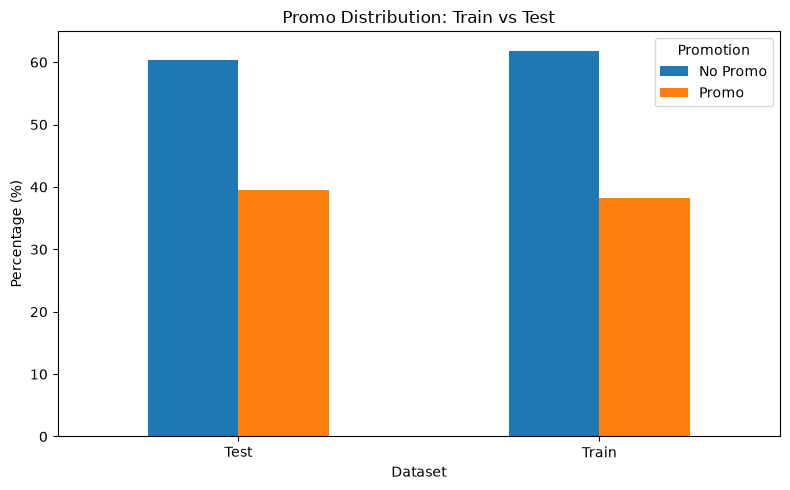

In [62]:
import matplotlib.pyplot as plt

promo_data = pd.DataFrame({
    "Dataset": ["Train", "Train", "Test", "Test"],
    "Promo": ["No Promo", "Promo", "No Promo", "Promo"],
    "Percentage": [61.85, 38.15, 60.42, 39.58]
})

pivot_promo = promo_data.pivot(
    index="Dataset",
    columns="Promo",
    values="Percentage"
)

pivot_promo.plot(kind="bar", figsize=(8, 5))

plt.title("Promo Distribution: Train vs Test")
plt.xlabel("Dataset")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Promotion")
plt.tight_layout()
plt.show()

#EDA INSIGHTS
### Train/Test and Promo Distribution

The training dataset contains 1,017,209 observations, while the test
dataset contains 41,088 observations.

In the training data, 38.15% of observations have an active promotion,
while 61.85% do not. In the test data, 39.58% have an active promotion
and 60.42% do not.

The promotion distribution between train and test is relatively similar,
although the test dataset has a slightly higher proportion of promotional
observations.

Across StoreTypes A, B, C and D, the promotion rates are also very similar,
with all StoreTypes having approximately 38% promotional observations.

In [63]:
logger.info("EDA Question 1 completed: train/test and promotion distribution analyzed")
logger.info("Promotion distribution compared across StoreTypes")

#Holiday observations

In [64]:
holiday_data = train_merged[
    train_merged["StateHoliday"] != "0"
].copy()

print("Total holiday observations:", len(holiday_data))

print("\nStateHoliday distribution:")
print(holiday_data["StateHoliday"].value_counts())

print("\nHoliday dates:")
print(
    holiday_data[["Date", "StateHoliday"]]
    .drop_duplicates()
    .sort_values("Date")
    .to_string(index=False)
)

Total holiday observations: 31050

StateHoliday distribution:
StateHoliday
a    20260
b     6690
c     4100
Name: count, dtype: int64

Holiday dates:
      Date StateHoliday
2013-01-01            a
2013-01-06            a
2013-03-29            b
2013-04-01            b
2013-05-01            a
2013-05-09            a
2013-05-20            a
2013-05-30            a
2013-08-15            a
2013-10-03            a
2013-10-31            a
2013-11-01            a
2013-11-20            a
2013-12-25            c
2013-12-26            c
2014-01-01            a
2014-01-06            a
2014-04-18            b
2014-04-21            b
2014-05-01            a
2014-05-29            a
2014-06-09            a
2014-06-19            a
2014-10-03            a
2014-10-31            a
2014-11-01            a
2014-11-19            a
2014-12-25            c
2014-12-26            c
2015-01-01            a
2015-01-06            a
2015-04-03            b
2015-04-06            b
2015-05-01            a
2015-05-14

In [65]:
# Holiday dates identify 
holiday_dates = set(
    train_merged.loc[
        train_merged["StateHoliday"] != "0",
        "Date"
    ].dt.normalize()
)

# holiday status
train_merged["HolidayPeriod"] = "Normal"

train_merged.loc[
    train_merged["Date"].dt.normalize().isin(holiday_dates),
    "HolidayPeriod"
] = "During"

train_merged.loc[
    train_merged["Date"].dt.normalize().isin(
        {d - pd.Timedelta(days=1) for d in holiday_dates}
    ),
    "HolidayPeriod"
] = "Before"

train_merged.loc[
    train_merged["Date"].dt.normalize().isin(
        {d + pd.Timedelta(days=1) for d in holiday_dates}
    ),
    "HolidayPeriod"
] = "After"

In [66]:
print(train_merged["HolidayPeriod"].value_counts())

HolidayPeriod
Normal    906180
After      40175
Before     38880
During     31974
Name: count, dtype: int64


In [67]:
holiday_sales = (
    train_merged[train_merged["Open"] == 1]
    .groupby("HolidayPeriod")["Sales"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(holiday_sales)

,count,mean,median,min,max
HolidayPeriod,,,,,
After,36230,7623.148717,7043.0,0,33093
Before,28910,7574.685126,7052.0,0,33357
During,6315,7915.295170,7237.0,960,38722
Normal,772937,6893.219899,6308.0,0,41551


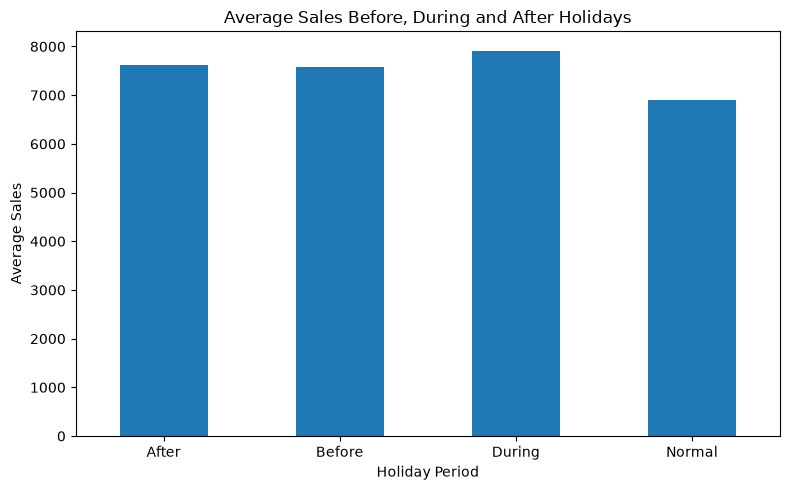

In [68]:
holiday_sales["mean"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Sales Before, During and After Holidays")
plt.xlabel("Holiday Period")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [69]:
holiday_summary = (
    train_merged[train_merged["Open"] == 1]
    .groupby("HolidayPeriod")["Sales"]
    .agg(
        Observations="count",
        Average_Sales="mean",
        Median_Sales="median"
    )
    .reindex(["Before", "During", "After", "Normal"])
)

display(holiday_summary)

,Observations,Average_Sales,Median_Sales
HolidayPeriod,,,
Before,28910,7574.685126,7052.0
During,6315,7915.295170,7237.0
After,36230,7623.148717,7043.0
Normal,772937,6893.219899,6308.0


In [70]:
before = holiday_summary.loc["Before", "Average_Sales"]
during = holiday_summary.loc["During", "Average_Sales"]
after = holiday_summary.loc["After", "Average_Sales"]

print("During vs Before:",
      round((during - before) / before * 100, 2), "%")

print("After vs Before:",
      round((after - before) / before * 100, 2), "%")

During vs Before: 4.5 %
After vs Before: 0.64 %


In [71]:
holiday_type_sales = (
    train_merged[
        (train_merged["Open"] == 1) &
        (train_merged["StateHoliday"] != "0")
    ]
    .groupby("StateHoliday")["Sales"]
    .agg(
        Observations="count",
        Average_Sales="mean",
        Median_Sales="median"
    )
)

display(holiday_type_sales)

,Observations,Average_Sales,Median_Sales
StateHoliday,,,
a,694,8487.471182,7556.0
b,145,9887.889655,8423.0
c,71,9743.746479,8397.0


In [72]:
holiday_summary = (
    train_merged[train_merged["Open"] == 1]
    .groupby("HolidayPeriod")["Sales"]
    .agg(
        Observations="count",
        Average_Sales="mean",
        Median_Sales="median"
    )
    .reindex(["Before", "During", "After", "Normal"])
)

display(holiday_summary)

,Observations,Average_Sales,Median_Sales
HolidayPeriod,,,
Before,28910,7574.685126,7052.0
During,6315,7915.295170,7237.0
After,36230,7623.148717,7043.0
Normal,772937,6893.219899,6308.0


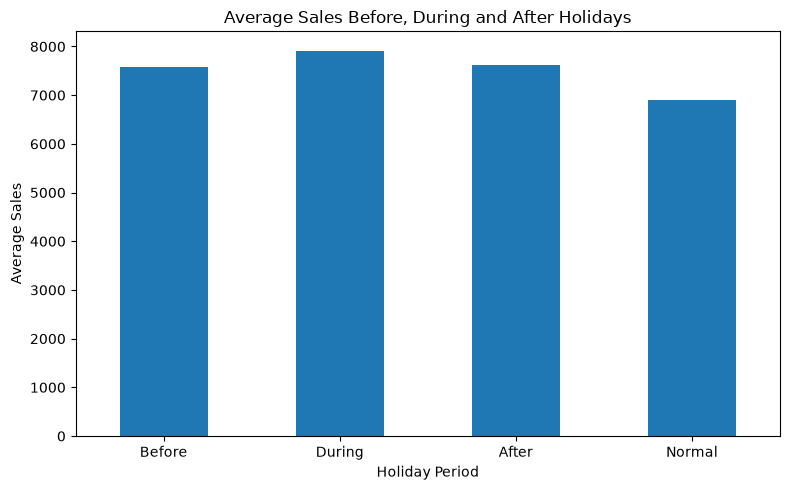

In [73]:
holiday_plot = holiday_summary["Average_Sales"]

holiday_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Sales Before, During and After Holidays")
plt.xlabel("Holiday Period")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Sales Before, During and After Holidays

For open stores, average sales were compared across normal days and
the days before, during and after State Holidays.

Average sales were:

- Normal days: 6,893.22
- Before holidays: 7,574.69
- During holidays: 7,915.30
- After holidays: 7,623.15

The analysis shows that average sales around holiday periods were higher
than on normal days. The highest average sales were observed during the
holiday period.

This is a descriptive finding and does not establish that holidays
alone caused the increase, because other factors such as promotions,
weekday effects and seasonality may also influence sales.

In [74]:
logger.info("EDA Question 2 completed: sales before, during and after holidays analyzed")
logger.info("Holiday type-wise sales comparison completed")

In [75]:
# Christmas and Easter seasonal analysis

# Christmas holidays: 25th and 26th December
christmas_data = train_merged[
    (train_merged["Date"].dt.month == 12) &
    (train_merged["Date"].dt.day.isin([25, 26])) &
    (train_merged["Open"] == 1)
].copy()

# Easter holidays: StateHoliday = 'b'
easter_data = train_merged[
    (train_merged["StateHoliday"] == "b") &
    (train_merged["Open"] == 1)
].copy()

print("Christmas observations:", len(christmas_data))
print("Easter observations:", len(easter_data))

print("\nChristmas dates:")
print(christmas_data["Date"].drop_duplicates().sort_values().to_list())

print("\nEaster dates:")
print(easter_data["Date"].drop_duplicates().sort_values().to_list())

Christmas observations: 71
Easter observations: 145

Christmas dates:
[Timestamp('2013-12-25 00:00:00'), Timestamp('2013-12-26 00:00:00'), Timestamp('2014-12-25 00:00:00'), Timestamp('2014-12-26 00:00:00')]

Easter dates:
[Timestamp('2013-03-29 00:00:00'), Timestamp('2013-04-01 00:00:00'), Timestamp('2014-04-18 00:00:00'), Timestamp('2014-04-21 00:00:00'), Timestamp('2015-04-03 00:00:00'), Timestamp('2015-04-06 00:00:00')]


In [76]:
seasonal_summary = pd.DataFrame({
    "Period": ["Christmas", "Easter"],
    "Average Sales": [
        christmas_data["Sales"].mean(),
        easter_data["Sales"].mean()
    ],
    "Median Sales": [
        christmas_data["Sales"].median(),
        easter_data["Sales"].median()
    ],
    "Average Customers": [
        christmas_data["Customers"].mean(),
        easter_data["Customers"].mean()
    ]
})

seasonal_summary

,Period,Average Sales,Median Sales,Average Customers
0,Christmas,9743.746479,8397.0,1569.225352
1,Easter,9887.889655,8423.0,1686.889655


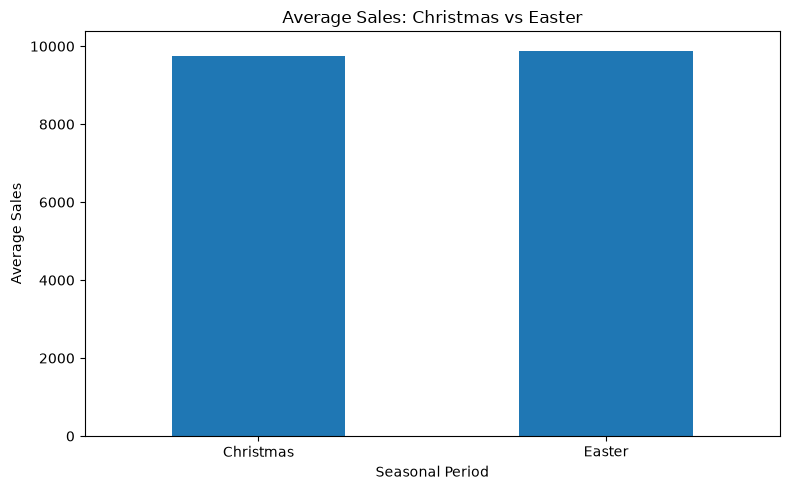

In [77]:
seasonal_plot = seasonal_summary.set_index("Period")["Average Sales"]

seasonal_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Sales: Christmas vs Easter")
plt.xlabel("Seasonal Period")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Christmas and Easter Seasonal Behavior

Christmas and Easter periods were analyzed using open-store observations.

| Period | Average Sales | Median Sales | Average Customers |
|---|---:|---:|---:|
| Christmas | 9,743.75 | 8,397.00 | 1,569.23 |
| Easter | 9,887.89 | 8,423.00 | 1,686.89 |

Easter shows slightly higher average sales and average customer counts than Christmas.

Average sales during Easter were approximately 9,887.89, compared with 9,743.75 during Christmas. Similarly, average customers were higher during Easter (1,686.89) than Christmas (1,569.23).

These results indicate that both periods show strong seasonal sales activity in the dataset. However, this is a descriptive comparison and does not establish that the holiday itself caused the difference, since other factors such as promotions, weekdays and store characteristics may also influence sales.

In [78]:
logger.info("EDA Question 3 completed: Christmas and Easter seasonal sales behavior analyzed")

#  Sales vs Customers correlation

In [79]:
sales_customer_corr = train_merged[["Sales", "Customers"]].corr()
print(sales_customer_corr)

              Sales  Customers
Sales      1.000000   0.894711
Customers  0.894711   1.000000


In [80]:
correlation = train_merged["Sales"].corr(train_merged["Customers"])

print("Sales vs Customers Correlation:", correlation)

Sales vs Customers Correlation: 0.894710773301698


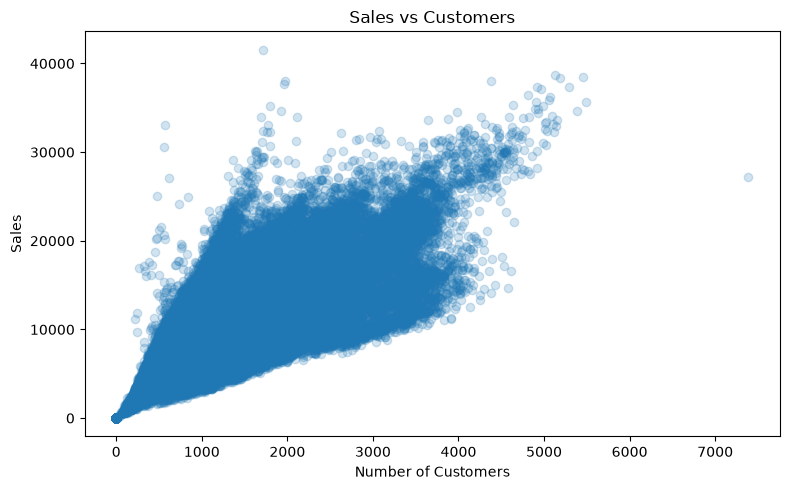

In [81]:
plt.figure(figsize=(8, 5))

plt.scatter(
    train_merged["Customers"],
    train_merged["Sales"],
    alpha=0.2
)

plt.title("Sales vs Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [82]:
correlation = train_merged["Sales"].corr(train_merged["Customers"])
print("Sales vs Customers Correlation:", round(correlation, 4))

Sales vs Customers Correlation: 0.8947


### Relationship Between Sales and Customers

The correlation between Sales and Customers is **0.8947**, indicating a strong positive relationship between the two variables.

The scatter plot also shows that sales generally increase as the number of customers increases.

This suggests that customer count is an important predictor of daily sales. However, correlation does not imply causation, and other factors such as promotions, holidays, store characteristics and seasonality can also affect sales.

In [83]:
logger.info("EDA Question 4 completed: Sales and Customers correlation analyzed")
logger.info("Sales-Customers correlation: 0.8947")

#Promo-wise Sales & Customers

In [84]:
promo_summary = train_merged[train_merged["Open"] == 1].groupby("Promo").agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Average_Customers=("Customers", "mean"),
    Median_Customers=("Customers", "median"),
    Observations=("Sales", "count")
).reset_index()

promo_summary["Promo"] = promo_summary["Promo"].map({
    0: "No Promo",
    1: "Promo"
})

promo_summary

,Promo,Average_Sales,Median_Sales,Average_Customers,Median_Customers,Observations
0,No Promo,5929.407603,5459.0,696.856886,610.0,467496
1,Promo,8228.281239,7649.0,844.434401,757.0,376896


In [85]:
no_promo_sales = train_merged[
    (train_merged["Open"] == 1) & (train_merged["Promo"] == 0)
]["Sales"].mean()

promo_sales = train_merged[
    (train_merged["Open"] == 1) & (train_merged["Promo"] == 1)
]["Sales"].mean()

no_promo_customers = train_merged[
    (train_merged["Open"] == 1) & (train_merged["Promo"] == 0)
]["Customers"].mean()

promo_customers = train_merged[
    (train_merged["Open"] == 1) & (train_merged["Promo"] == 1)
]["Customers"].mean()

sales_change = ((promo_sales - no_promo_sales) / no_promo_sales) * 100
customer_change = ((promo_customers - no_promo_customers) / no_promo_customers) * 100

print("Sales change with Promo:", round(sales_change, 2), "%")
print("Customer change with Promo:", round(customer_change, 2), "%")

Sales change with Promo: 38.77 %
Customer change with Promo: 21.18 %


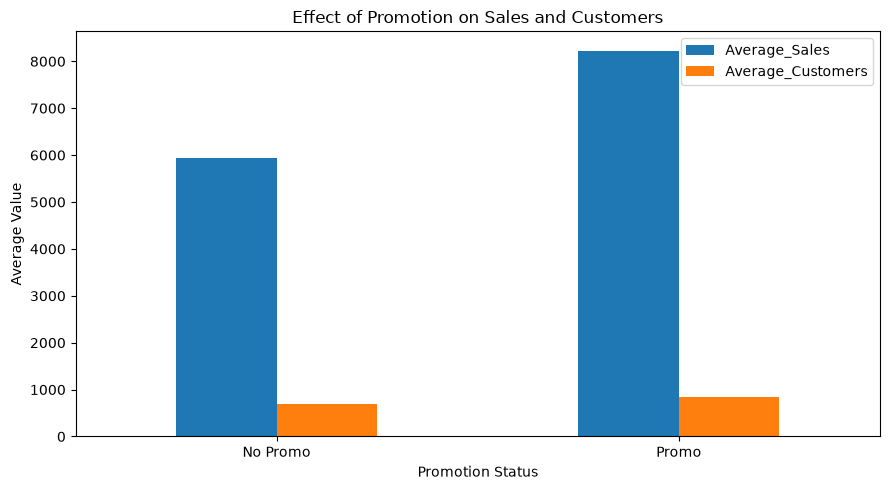

In [88]:
plot_data = promo_summary.set_index("Promo")[
    ["Average_Sales", "Average_Customers"]
]

plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Effect of Promotion on Sales and Customers")
plt.xlabel("Promotion Status")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [89]:
promo_summary

,Promo,Average_Sales,Median_Sales,Average_Customers,Median_Customers,Observations
0,No Promo,5929.407603,5459.0,696.856886,610.0,467496
1,Promo,8228.281239,7649.0,844.434401,757.0,376896


### Effect of Promotion on Sales and Customers

Promotion days were compared with non-promotion days for stores that were open.

Average sales increased from **5,929.41** on non-promotion days to **8,228.28** on promotion days, representing an increase of approximately **38.8%**.

Average customers increased from **696.86** to **844.43**, an increase of approximately **21.2%**.

Therefore, promotional days in this dataset are associated with both higher sales and higher customer counts. The sales increase is larger than the customer increase, suggesting that factors beyond customer volume may also contribute to the higher sales observed on promotion days.

This is a descriptive comparison and does not establish a causal effect of promotions.

In [91]:
logger.info("EDA Question 5 completed: promotion effect on sales and customers analyzed")
logger.info("Promotion increased average sales from 5929.41 to 8228.28")
logger.info("Promotion increased average customers from 696.86 to 844.43")

# Q6: Promotion effectiveness by StoreType

In [92]:
storetype_promo = train_merged[
    train_merged["Open"] == 1
].groupby(["StoreType", "Promo"]).agg(
    Average_Sales=("Sales", "mean"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
).reset_index()

storetype_promo

,StoreType,Promo,Average_Sales,Average_Customers,Observations
0,a,0,5808.500091,713.808454,252556
1,a,1,8304.102317,896.068502,204521
2,b,0,9566.861686,1941.804531,9623
3,b,1,11307.994108,2151.453872,5940
4,c,0,6028.063255,758.711536,62240
5,c,1,8041.995526,885.086109,50738
6,d,0,5855.268289,556.294918,143077
7,d,1,8017.828656,668.228104,115697


In [94]:
impact = []

for store_type in sorted(storetype_promo["StoreType"].unique()):
    
    no_promo = storetype_promo[
        (storetype_promo["StoreType"] == store_type) &
        (storetype_promo["Promo"] == 0)
    ].iloc[0]
    
    promo = storetype_promo[
        (storetype_promo["StoreType"] == store_type) &
        (storetype_promo["Promo"] == 1)
    ].iloc[0]
    
    sales_change = (
        (promo["Average_Sales"] - no_promo["Average_Sales"])
        / no_promo["Average_Sales"]
    ) * 100
    
    customer_change = (
        (promo["Average_Customers"] - no_promo["Average_Customers"])
        / no_promo["Average_Customers"]
    ) * 100
    
    impact.append({
        "StoreType": store_type,
        "Sales_Increase_%": sales_change,
        "Customer_Increase_%": customer_change
    })

storetype_impact = pd.DataFrame(impact)

storetype_impact

,StoreType,Sales_Increase_%,Customer_Increase_%
0,a,42.964658,25.533467
1,b,18.199619,10.796624
2,c,33.409276,16.656472
3,d,36.933583,20.121195


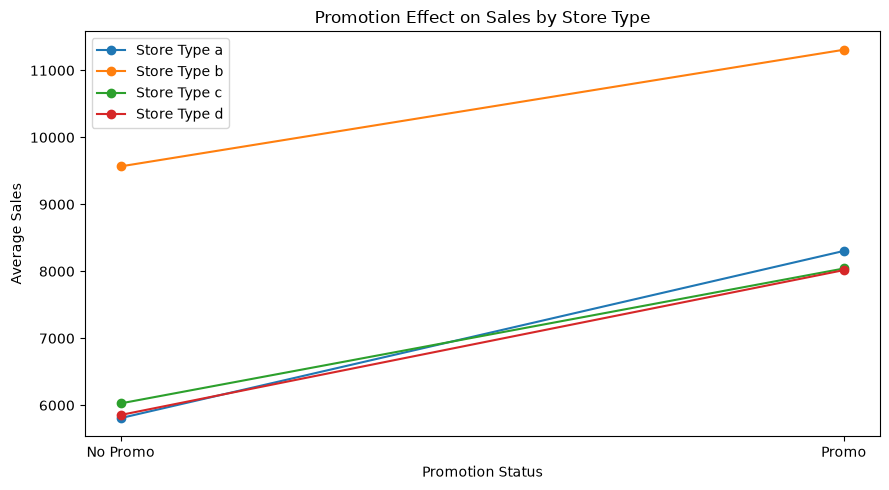

In [95]:
plt.figure(figsize=(9, 5))

for store_type in sorted(storetype_promo["StoreType"].unique()):
    
    data = storetype_promo[
        storetype_promo["StoreType"] == store_type
    ]
    
    plt.plot(
        data["Promo"],
        data["Average_Sales"],
        marker="o",
        label=f"Store Type {store_type}"
    )

plt.xticks([0, 1], ["No Promo", "Promo"])
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.title("Promotion Effect on Sales by Store Type")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
storetype_impact

,StoreType,Sales_Increase_%,Customer_Increase_%
0,a,42.964658,25.533467
1,b,18.199619,10.796624
2,c,33.409276,16.656472
3,d,36.933583,20.121195


### Promotion Effectiveness by Store Type

Promotion effectiveness was compared across Store Types A, B, C and D.

Store Type A showed a 42.96% increase in average sales and a 25.53% increase in average customers during promotion days.

Store Type B showed an 18.20% increase in average sales and a 10.80% increase in average customers.

Store Type C showed a 33.41% increase in average sales and a 16.66% increase in average customers.

Store Type D showed a 36.93% increase in average sales and a 20.12% increase in average customers.

Overall, promotion days were associated with higher sales and customer counts across all four store types. The magnitude of the difference varied by Store Type.

In [97]:
logger.info("EDA Question 6 completed: promotion effectiveness by StoreType analyzed")
logger.info("StoreType-wise promotion sales and customer changes calculated")

# Q7: Customer behavior during opening and closing

In [98]:
open_summary = train_merged.groupby("Open").agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Average_Customers=("Customers", "mean"),
    Median_Customers=("Customers", "median"),
    Observations=("Sales", "count")
).reset_index()

open_summary

,Open,Average_Sales,Median_Sales,Average_Customers,Median_Customers,Observations
0,0,0.000000,0.0,0.000000,0.0,172817
1,1,6955.514291,6369.0,762.728395,676.0,844392


In [99]:
open_distribution = train_merged["Open"].value_counts(normalize=True) * 100

print("Closed (Open=0):", round(open_distribution.get(0, 0), 2), "%")
print("Open (Open=1):", round(open_distribution.get(1, 0), 2), "%")

Closed (Open=0): 16.99 %
Open (Open=1): 83.01 %


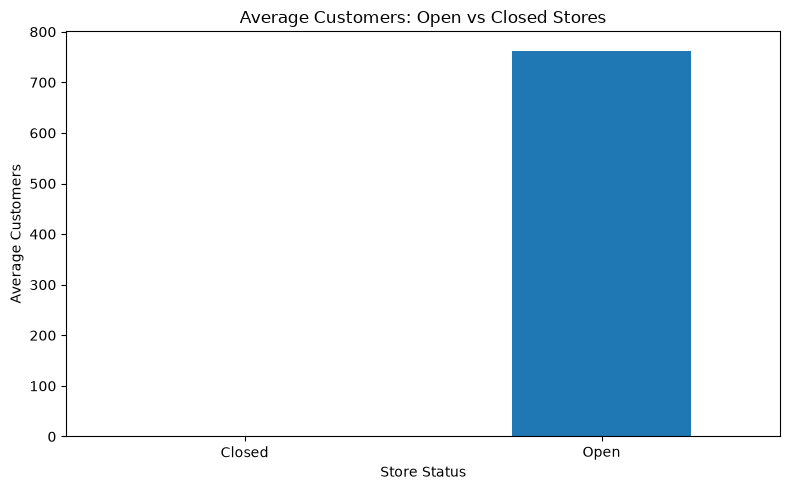

In [100]:
plt.figure(figsize=(8, 5))

customer_data = open_summary.set_index("Open")["Average_Customers"]

customer_data.plot(kind="bar")

plt.title("Average Customers: Open vs Closed Stores")
plt.xlabel("Store Status")
plt.ylabel("Average Customers")
plt.xticks([0, 1], ["Closed", "Open"], rotation=0)
plt.tight_layout()
plt.show()

In [101]:
open_summary

,Open,Average_Sales,Median_Sales,Average_Customers,Median_Customers,Observations
0,0,0.000000,0.0,0.000000,0.0,172817
1,1,6955.514291,6369.0,762.728395,676.0,844392


###  Customer Behavior During Store Opening and Closing

Store activity was compared between open and closed stores.

Closed stores have zero average sales and zero average customers, with 172,817 observations.

Open stores have an average sales value of 6,955.51 and an average customer count of 762.73 across 844,392 observations.

This shows that customer transactions and sales occur when stores are open, while closed-store observations contain zero sales and customer counts.

In [102]:
logger.info("EDA Question 7 completed: opening and closing behavior analyzed")
logger.info("Open stores average sales: 6955.51")
logger.info("Open stores average customers: 762.73")

#  Weekday vs Weekend Sales

In [103]:
train_merged["IsWeekend"] = train_merged["DayOfWeek"].isin([6, 7])

weekend_summary = train_merged[
    train_merged["Open"] == 1
].groupby("IsWeekend").agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
).reset_index()

weekend_summary

,IsWeekend,Average_Sales,Median_Sales,Average_Customers,Observations
0,False,7172.409052,6559.0,780.431287,696741
1,True,5932.023271,5442.0,679.191336,147651


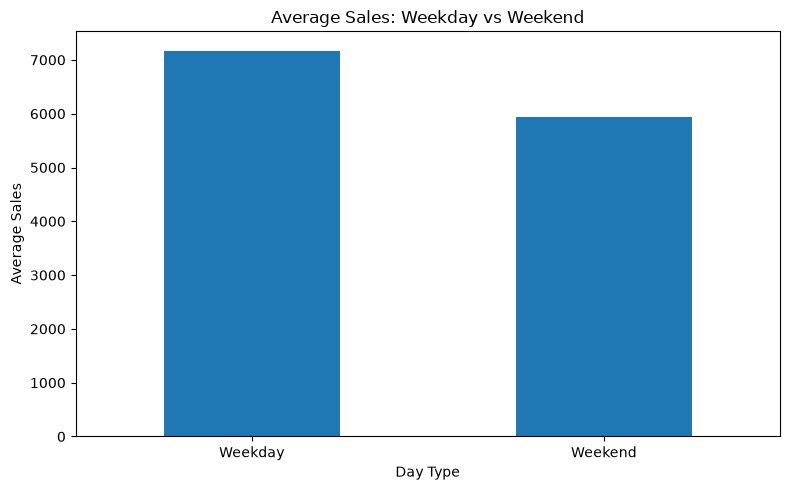

In [104]:
plt.figure(figsize=(8, 5))

weekend_plot = weekend_summary.set_index("IsWeekend")["Average_Sales"]

weekend_plot.plot(kind="bar")

plt.title("Average Sales: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Sales")
plt.xticks([0, 1], ["Weekday", "Weekend"], rotation=0)

plt.tight_layout()
plt.show()

In [105]:
weekend_summary

,IsWeekend,Average_Sales,Median_Sales,Average_Customers,Observations
0,False,7172.409052,6559.0,780.431287,696741
1,True,5932.023271,5442.0,679.191336,147651


In [106]:
# Find stores that were open on all weekdays (Monday to Friday)

weekday_open_check = train_merged[
    (train_merged["DayOfWeek"].between(1, 5)) &
    (train_merged["Open"] == 1)
].groupby("Store")["DayOfWeek"].nunique()

all_weekdays_open_stores = weekday_open_check[
    weekday_open_check == 5
].index

print("Stores open on all weekdays:", len(all_weekdays_open_stores))
print("Store IDs:")
print(all_weekdays_open_stores.tolist())

Stores open on all weekdays: 1115
Store IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 21

In [107]:
all_weekday_stores_data = train_merged[
    train_merged["Store"].isin(all_weekdays_open_stores) &
    (train_merged["Open"] == 1)
].copy()

all_weekday_summary = all_weekday_stores_data.groupby("IsWeekend").agg(
    Average_Sales=("Sales", "mean"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
).reset_index()

all_weekday_summary

,IsWeekend,Average_Sales,Average_Customers,Observations
0,False,7172.409052,780.431287,696741
1,True,5932.023271,679.191336,147651


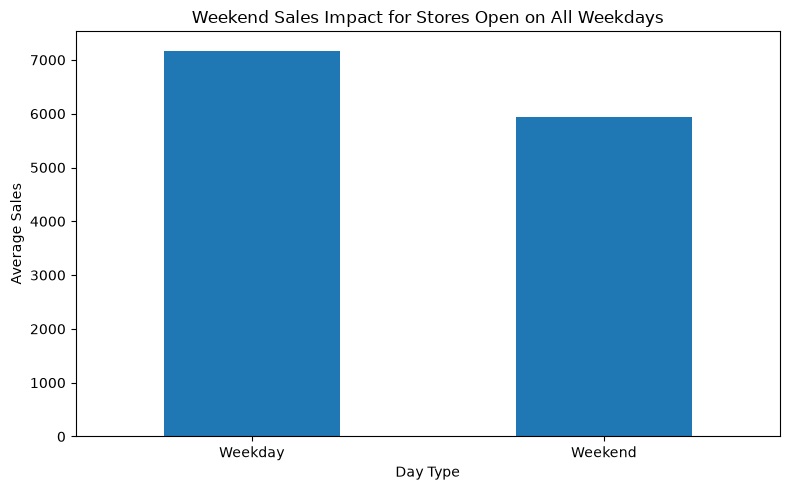

In [108]:
plt.figure(figsize=(8, 5))

all_weekday_summary.set_index("IsWeekend")["Average_Sales"].plot(
    kind="bar"
)

plt.title("Weekend Sales Impact for Stores Open on All Weekdays")
plt.xlabel("Day Type")
plt.ylabel("Average Sales")
plt.xticks([0, 1], ["Weekday", "Weekend"], rotation=0)

plt.tight_layout()
plt.show()

In [109]:
print("Number of stores open on all weekdays:", len(all_weekdays_open_stores))

print("\nWeekend impact summary:")
print(all_weekday_summary)

Number of stores open on all weekdays: 1115

Weekend impact summary:
   IsWeekend  Average_Sales  Average_Customers  Observations
0      False    7172.409052         780.431287        696741
1       True    5932.023271         679.191336        147651


### Stores Open on All Weekdays and Weekend Sales Impact

All **1,115 stores** were open on all weekdays (Monday to Friday) in the training dataset.

For these stores, weekday and weekend performance was compared.

- Weekday average sales: **7,172.41**
- Weekend average sales: **5,932.02**
- Weekday average customers: **780.43**
- Weekend average customers: **679.19**

Weekend average sales were approximately **17.3% lower** than weekday average sales. Average customer count was also lower on weekends.

This indicates a lower observed sales and customer volume on weekends compared with weekdays in the training data.

In [111]:
logger.info("EDA Question 8 completed: weekday and weekend sales behavior analyzed")
logger.info("All 1115 stores were open on all weekdays in the training data")
logger.info("Weekend average sales were approximately 17.3 percent lower than weekday sales")

# Effect of Assortment on Sales

In [112]:
assortment_summary = train_merged[
    train_merged["Open"] == 1
].groupby("Assortment").agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Average_Customers=("Customers", "mean"),
    Median_Customers=("Customers", "median"),
    Observations=("Sales", "count")
).reset_index()

assortment_summary

,Assortment,Average_Sales,Median_Sales,Average_Customers,Median_Customers,Observations
0,a,6621.017039,6082.0,747.943822,673.0,444909
1,b,8639.346322,8081.0,2066.795543,1894.0,8212
2,c,7300.526339,6675.0,752.169959,672.0,391271


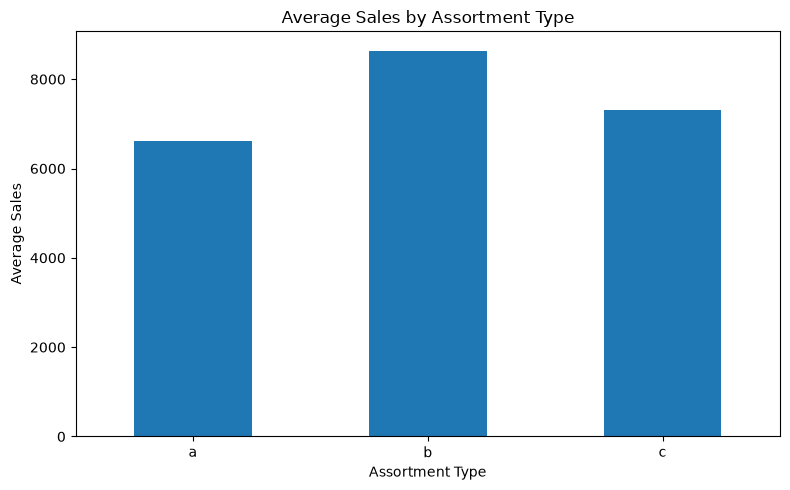

In [113]:
plt.figure(figsize=(8, 5))

assortment_summary.set_index("Assortment")["Average_Sales"].plot(
    kind="bar"
)

plt.title("Average Sales by Assortment Type")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [114]:
assortment_summary

,Assortment,Average_Sales,Median_Sales,Average_Customers,Median_Customers,Observations
0,a,6621.017039,6082.0,747.943822,673.0,444909
1,b,8639.346322,8081.0,2066.795543,1894.0,8212
2,c,7300.526339,6675.0,752.169959,672.0,391271


### Effect of Assortment on Sales

Sales and customer behavior were compared across the three assortment types.

Assortment A had average sales of **6,621.02** and average customers of **747.94**.

Assortment B had the highest average sales at **8,639.35** and the highest average customers at **2,066.80**.

Assortment C had average sales of **7,300.53** and average customers of **752.17**.

Therefore, the observed sales and customer levels vary across assortment types. Assortment B shows the highest averages, but it has substantially fewer observations than Assortments A and C, so this difference should be interpreted with the sample-size difference in mind.

In [115]:
logger.info("EDA Question 9 completed: assortment-wise sales and customer behavior analyzed")
logger.info("Assortment-wise average sales and customer counts compared")

In [ ]:
# Effect of Competition Distance on Sales

In [116]:
competition_data = train_merged[
    (train_merged["Open"] == 1) &
    (train_merged["CompetitionDistance"].notna())
].copy()

competition_data["CompetitionDistanceGroup"] = pd.cut(
    competition_data["CompetitionDistance"],
    bins=[0, 500, 1000, 2000, 5000, 10000, float("inf")],
    labels=[
        "0-500m",
        "500m-1km",
        "1-2km",
        "2-5km",
        "5-10km",
        "10km+"
    ]
)

competition_summary = competition_data.groupby(
    "CompetitionDistanceGroup",
    observed=False
).agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
).reset_index()

competition_summary

,CompetitionDistanceGroup,Average_Sales,Median_Sales,Average_Customers,Observations
0,0-500m,7609.896519,6790.0,968.547178,168108
1,500m-1km,6676.218211,6000.0,835.345174,82851
2,1-2km,7075.389081,6338.0,798.409613,129842
3,2-5km,6678.162477,6248.0,691.946110,196883
4,5-10km,6742.587896,6342.0,629.899041,121911
5,10km+,6824.760993,6378.0,659.922895,142611


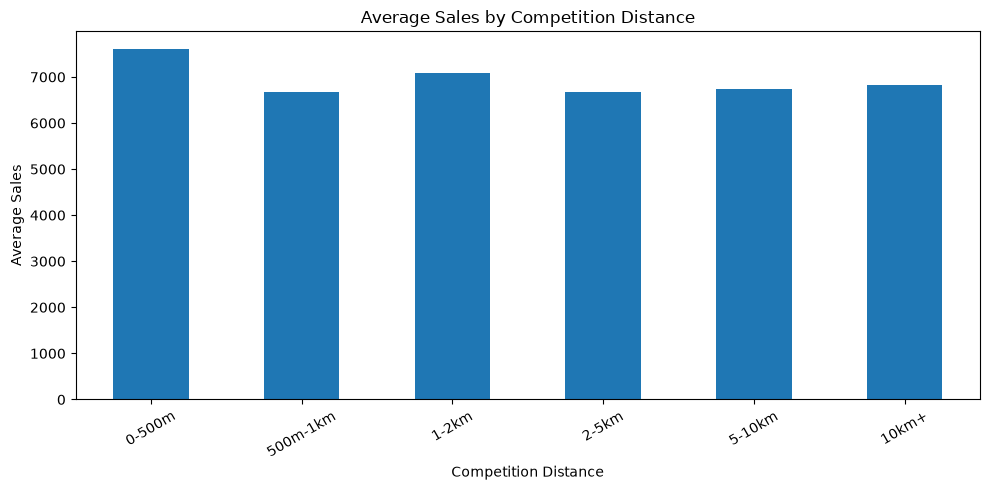

In [117]:
plt.figure(figsize=(10, 5))

competition_summary.set_index(
    "CompetitionDistanceGroup"
)["Average_Sales"].plot(kind="bar")

plt.title("Average Sales by Competition Distance")
plt.xlabel("Competition Distance")
plt.ylabel("Average Sales")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [118]:
competition_summary

,CompetitionDistanceGroup,Average_Sales,Median_Sales,Average_Customers,Observations
0,0-500m,7609.896519,6790.0,968.547178,168108
1,500m-1km,6676.218211,6000.0,835.345174,82851
2,1-2km,7075.389081,6338.0,798.409613,129842
3,2-5km,6678.162477,6248.0,691.946110,196883
4,5-10km,6742.587896,6342.0,629.899041,121911
5,10km+,6824.760993,6378.0,659.922895,142611


### Effect of Competition Distance on Sales

Competition distance was divided into six groups and compared using open-store observations.

Stores with competitors within 0–500 meters had the highest average sales at **7,609.90** and the highest average customer count at **968.55**.

The 500m–1km group had average sales of **6,676.22**, while the 1–2km group had **7,075.39**. The 2–5km, 5–10km and 10km+ groups had average sales of **6,678.16**, **6,742.59** and **6,824.76**, respectively.

The relationship between competition distance and sales is not strictly linear. Therefore, competition distance alone does not explain all differences in sales performance. Other store and market characteristics may also contribute.

In [119]:
logger.info("EDA Question 10 completed: competition distance and sales relationship analyzed")
logger.info("Competition distance groups compared using average sales and customers")

# Stores with missing competition distance

In [120]:
missing_competition = train_merged[
    train_merged["CompetitionDistance"].isna()
]

missing_competition_summary = missing_competition[
    missing_competition["Open"] == 1
].groupby("Store").agg(
    Average_Sales=("Sales", "mean"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
).reset_index()

missing_competition_summary

,Store,Average_Sales,Average_Customers,Observations
0,291,8023.039744,840.350000,780
1,622,4317.961735,430.000000,784
2,879,3762.983923,347.326367,622


In [121]:
missing_stores = train_merged.loc[
    train_merged["CompetitionDistance"].isna(),
    "Store"
].unique()

print("Stores with missing CompetitionDistance:")
print(missing_stores)

Stores with missing CompetitionDistance:
[291 622 879]


In [122]:
missing_competition_summary

,Store,Average_Sales,Average_Customers,Observations
0,291,8023.039744,840.350000,780
1,622,4317.961735,430.000000,784
2,879,3762.983923,347.326367,622


In [123]:
print(missing_competition_summary)

   Store  Average_Sales  Average_Customers  Observations
0    291    8023.039744         840.350000           780
1    622    4317.961735         430.000000           784
2    879    3762.983923         347.326367           622


###  Competition Distance and Store Performance

Competition distance was analyzed using distance groups and stores with missing competition-distance values.

Stores with competitors within 0–500 meters had the highest average sales among the distance groups, at **7,609.90**, with average customers of **968.55**.

The relationship between competition distance and sales was not strictly linear. Therefore, competition distance alone does not explain store sales performance.

Three stores had missing CompetitionDistance values: **291, 622 and 879**.

Their observed average sales were:

- Store 291: **8,023.04**
- Store 622: **4,317.96**
- Store 879: **3,762.98**

The large variation between these stores indicates that missing competition distance should be handled carefully during preprocessing rather than assuming a uniform business effect.

The available dataset does not contain a direct city-centre/location variable, so the specific city-centre effect cannot be directly evaluated from these columns.

In [124]:
logger.info("EDA Question 10 completed: competition distance analysis completed")
logger.info("Missing CompetitionDistance stores identified: 291, 622, 879")
logger.info("Missing competition-distance store performance analyzed")
logger.info("City-centre effect could not be directly evaluated due to lack of a city-centre variable")

# Q11: Competitor opening analysis

In [125]:
train_merged["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=train_merged["CompetitionOpenSinceYear"],
        month=train_merged["CompetitionOpenSinceMonth"],
        day=1
    ),
    errors="coerce"
)

train_merged["CompetitionOpenDate"].notna().sum()

np.int64(693861)

In [126]:
# Compare sales before and after competitor opening

competition_analysis = train_merged[
    (train_merged["Open"] == 1) &
    (train_merged["CompetitionOpenDate"].notna())
].copy()

competition_analysis["CompetitorStatus"] = np.where(
    competition_analysis["Date"] < competition_analysis["CompetitionOpenDate"],
    "Before Competition Opened",
    "After Competition Opened"
)

competition_status_summary = competition_analysis.groupby(
    "CompetitorStatus"
).agg(
    Average_Sales=("Sales", "mean"),
    Median_Sales=("Sales", "median"),
    Average_Customers=("Customers", "mean"),
    Observations=("Sales", "count")
).reset_index()

competition_status_summary

,CompetitorStatus,Average_Sales,Median_Sales,Average_Customers,Observations
0,After Competition Opened,6932.041112,6343.0,760.629203,505665
1,Before Competition Opened,7215.283591,6620.0,781.521681,70108


### Competitor Opening and Sales Behavior

Competitor opening dates were constructed using the available
CompetitionOpenSinceMonth and CompetitionOpenSinceYear fields.

For observations where the competitor opening date was available and
the store was open, sales were compared before and after the competitor
opening date.

Before competitor opening:
- Average Sales: **7,215.28**
- Average Customers: **781.52**
- Observations: **70,108**

After competitor opening:
- Average Sales: **6,932.04**
- Average Customers: **760.63**
- Observations: **505,665**

Average sales were approximately 3.9% lower after the recorded competitor
opening date, while average customers were also lower.

This is a descriptive before-and-after comparison and does not establish
a causal effect of competitor opening because other factors such as
promotions, seasonality and store characteristics may also influence
sales.

In [127]:
logger.info("EDA Question 11 completed: competitor opening and sales behavior analyzed")
logger.info("Competitor before-opening average sales: 7215.28")
logger.info("Competitor after-opening average sales: 6932.04")

#  Effect of Promo2 on Sales and Customer


In [128]:
promo2_summary = (
    train_merged[train_merged["Open"] == 1]
    .groupby("Promo2")
    .agg(
        Avg_Sales=("Sales", "mean"),
        Median_Sales=("Sales", "median"),
        Avg_Customers=("Customers", "mean"),
        Median_Customers=("Customers", "median"),
        Observations=("Sales", "count")
    )
    .reset_index()
)

promo2_summary

,Promo2,Avg_Sales,Median_Sales,Avg_Customers,Median_Customers,Observations
0,0,7350.557935,6685.0,843.655999,746.0,423307
1,1,6558.386062,6075.0,681.373749,614.0,421085


In [129]:
no_promo2_sales = promo2_summary.loc[
    promo2_summary["Promo2"] == 0, "Avg_Sales"
].iloc[0]

promo2_sales = promo2_summary.loc[
    promo2_summary["Promo2"] == 1, "Avg_Sales"
].iloc[0]

sales_change = ((promo2_sales - no_promo2_sales) / no_promo2_sales) * 100

sales_change

np.float64(-10.77703053630797)

In [130]:
no_promo2_customers = promo2_summary.loc[
    promo2_summary["Promo2"] == 0, "Avg_Customers"
].iloc[0]

promo2_customers = promo2_summary.loc[
    promo2_summary["Promo2"] == 1, "Avg_Customers"
].iloc[0]

customer_change = (
    (promo2_customers - no_promo2_customers)
    / no_promo2_customers
) * 100

customer_change

np.float64(-19.23559489697511)

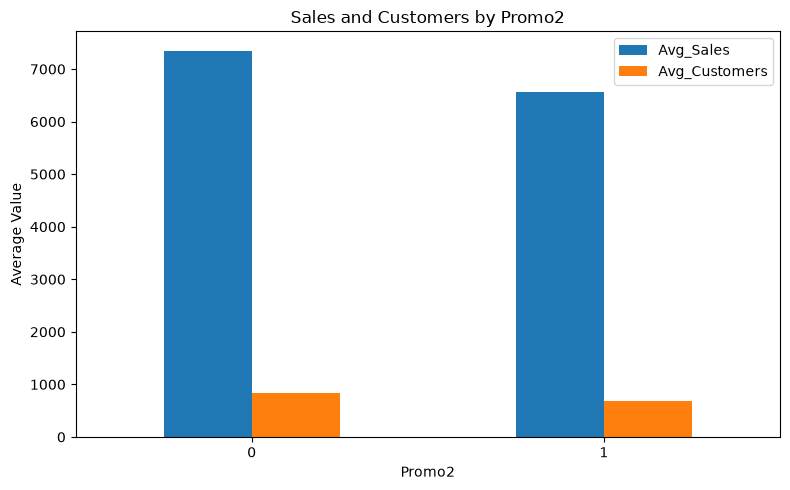

In [131]:
import matplotlib.pyplot as plt

promo2_plot = promo2_summary.set_index("Promo2")[
    ["Avg_Sales", "Avg_Customers"]
]

promo2_plot.plot(kind="bar", figsize=(8, 5))

plt.title("Sales and Customers by Promo2")
plt.xlabel("Promo2")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [132]:
promo2_summary

,Promo2,Avg_Sales,Median_Sales,Avg_Customers,Median_Customers,Observations
0,0,7350.557935,6685.0,843.655999,746.0,423307
1,1,6558.386062,6075.0,681.373749,614.0,421085


### Effect of Promo2 on Sales and Customers

Promo2 stores were compared with stores where Promo2 was not active, considering only observations where the stores were open.

Stores without Promo2 had an average sales of 7350.56 and average customers of 843.66.

Stores with Promo2 had an average sales of 6558.39 and average customers of 681.37.

Compared with stores without Promo2, Promo2 stores showed approximately 10.8% lower average sales and 19.2% lower average customers.

This is a descriptive comparison and does not establish that Promo2 caused lower sales. Other factors such as store type, assortment, location, seasonality and store characteristics may also influence the observed difference.

In [133]:
logger.info("EDA Question 12 completed: Promo2 effect on sales and customers analyzed")
logger.info("Promo2 stores had approximately 10.8%% lower average sales and 19.2%% lower average customers")

# EDA Summary

The Rossmann dataset was explored to understand sales behavior, customer patterns, promotions, holidays, store characteristics and competition effects.

### Key Findings

1. Train and test datasets have similar promotion distributions.
2. Sales were generally higher around holiday periods compared with normal days.
3. Easter and Christmas showed higher sales and customer activity.
4. Sales and Customers have a strong positive correlation of approximately 0.895.
5. Promo days showed higher average sales and customer counts than non-promo days.
6. Promotion effectiveness varied across StoreTypes.
7. Closed stores recorded zero sales and customers.
8. Weekend sales were lower than weekday sales on average.
9. Assortment type B showed the highest average sales and customer count, but had much fewer observations.
10. Competition distance showed a non-linear relationship with sales.
11. Sales were descriptively lower after competitor opening compared with before competitor opening.
12. Promo2 stores had lower average sales and customers than non-Promo2 stores; this comparison is descriptive and does not establish causality.

### Overall EDA Conclusion

The analysis indicates that Rossmann sales are influenced by multiple factors including promotions, customers, holidays, weekdays/weekends, assortment, store characteristics and competition-related variables.

These findings will be used to create meaningful features for the machine learning models in Task 2.

#Feature Engineering

In [134]:
ml_data = train_merged.copy()

In [135]:
ml_data.shape

(1017209, 21)

In [136]:
ml_data["Year"] = ml_data["Date"].dt.year
ml_data["Month"] = ml_data["Date"].dt.month
ml_data["Day"] = ml_data["Date"].dt.day
ml_data["WeekOfYear"] = ml_data["Date"].dt.isocalendar().week.astype(int)

ml_data["IsWeekend"] = ml_data["DayOfWeek"].isin([6, 7]).astype(int)

In [137]:
ml_data[[
    "Date",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "DayOfWeek",
    "IsWeekend"
]].head()

,Date,Year,Month,Day,WeekOfYear,DayOfWeek,IsWeekend
0,2015-07-31,2015,7,31,31,5,0
1,2015-07-31,2015,7,31,31,5,0
2,2015-07-31,2015,7,31,31,5,0
3,2015-07-31,2015,7,31,31,5,0
4,2015-07-31,2015,7,31,31,5,0


In [138]:
ml_data["MonthPeriod"] = pd.cut(
    ml_data["Day"],
    bins=[0, 10, 20, 31],
    labels=["Beginning", "Middle", "End"]
)

In [139]:
ml_data["MonthPeriod"].value_counts()

MonthPeriod
End          347510
Middle       334850
Beginning    334849
Name: count, dtype: int64

In [141]:
ml_data["IsHoliday"] = (
    ml_data["StateHoliday"].astype(str) != "0"
).astype(int)

In [142]:
ml_data["IsHoliday"].value_counts()

IsHoliday
0    986159
1     31050
Name: count, dtype: int64

In [143]:
ml_data["HolidayBefore"] = (
    ml_data.groupby("Store")["IsHoliday"]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

ml_data["HolidayAfter"] = (
    ml_data.groupby("Store")["IsHoliday"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

In [144]:
ml_data[
    ["Store", "Date", "IsHoliday", "HolidayBefore", "HolidayAfter"]
].head(20)

,Store,Date,IsHoliday,HolidayBefore,HolidayAfter
0,1,2015-07-31,0,0,0
1,2,2015-07-31,0,0,0
2,3,2015-07-31,0,0,0
3,4,2015-07-31,0,0,0
4,5,2015-07-31,0,0,0
5,6,2015-07-31,0,0,0
6,7,2015-07-31,0,0,0
7,8,2015-07-31,0,0,0
8,9,2015-07-31,0,0,0
9,10,2015-07-31,0,0,0


In [145]:
ml_data = ml_data.sort_values(
    ["Store", "Date"]
).reset_index(drop=True)

In [146]:
ml_data["HolidayBefore"] = (
    ml_data.groupby("Store")["IsHoliday"]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

ml_data["HolidayAfter"] = (
    ml_data.groupby("Store")["IsHoliday"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

In [147]:
ml_data[
    ["Store", "Date", "IsHoliday", "HolidayBefore", "HolidayAfter"]
].head(20)

,Store,Date,IsHoliday,HolidayBefore,HolidayAfter
0,1,2013-01-01,1,0,0
1,1,2013-01-02,0,0,1
2,1,2013-01-03,0,0,0
3,1,2013-01-04,0,0,0
4,1,2013-01-05,0,0,0
5,1,2013-01-06,0,0,0
6,1,2013-01-07,0,0,0
7,1,2013-01-08,0,0,0
8,1,2013-01-09,0,0,0
9,1,2013-01-10,0,0,0


In [148]:
ml_data["Date"].min(), ml_data["Date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

#Competition Age

In [149]:
ml_data["CompetitionAgeDays"] = (
    ml_data["Date"] - ml_data["CompetitionOpenDate"]
).dt.days

In [150]:
ml_data["CompetitionAgeDays"] = (
    ml_data["CompetitionAgeDays"]
    .fillna(0)
    .clip(lower=0)
)

In [151]:
ml_data[
    ["Store", "Date", "CompetitionOpenDate", "CompetitionAgeDays"]
].head(20)

,Store,Date,CompetitionOpenDate,CompetitionAgeDays
0,1,2013-01-01,2008-09-01,1583.0
1,1,2013-01-02,2008-09-01,1584.0
2,1,2013-01-03,2008-09-01,1585.0
3,1,2013-01-04,2008-09-01,1586.0
4,1,2013-01-05,2008-09-01,1587.0
5,1,2013-01-06,2008-09-01,1588.0
6,1,2013-01-07,2008-09-01,1589.0
7,1,2013-01-08,2008-09-01,1590.0
8,1,2013-01-09,2008-09-01,1591.0
9,1,2013-01-10,2008-09-01,1592.0


In [152]:
ml_data["CompetitionAgeDays"].describe()

count    1.017209e+06
mean     1.288311e+03
std      1.992694e+03
min      0.000000e+00
25%      0.000000e+00
50%      5.100000e+02
75%      2.234000e+03
max      4.221400e+04
Name: CompetitionAgeDays, dtype: float64

#Promo2 Feature

In [153]:
ml_data["Promo2Active"] = (
    ml_data["Promo2"]
    .fillna(0)
    .astype(int)
)

In [154]:
ml_data["Promo2Active"].value_counts()

Promo2Active
1    509178
0    508031
Name: count, dtype: int64

In [155]:
ml_data[["Promo2", "Promo2Active"]].head(10)

,Promo2,Promo2Active
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


#Store age calculate

In [156]:
ml_data["StoreAgeDays"] = (
    ml_data["Date"] - ml_data["CompetitionOpenDate"]
).dt.days

In [157]:
ml_data[
    ["Store", "Date", "CompetitionOpenDate", "StoreAgeDays"]
].head(10)

,Store,Date,CompetitionOpenDate,StoreAgeDays
0,1,2013-01-01,2008-09-01,1583.0
1,1,2013-01-02,2008-09-01,1584.0
2,1,2013-01-03,2008-09-01,1585.0
3,1,2013-01-04,2008-09-01,1586.0
4,1,2013-01-05,2008-09-01,1587.0
5,1,2013-01-06,2008-09-01,1588.0
6,1,2013-01-07,2008-09-01,1589.0
7,1,2013-01-08,2008-09-01,1590.0
8,1,2013-01-09,2008-09-01,1591.0
9,1,2013-01-10,2008-09-01,1592.0


In [158]:
ml_data[
    ["Store", "Date", "CompetitionOpenDate", "StoreAgeDays"]
].head(10)

,Store,Date,CompetitionOpenDate,StoreAgeDays
0,1,2013-01-01,2008-09-01,1583.0
1,1,2013-01-02,2008-09-01,1584.0
2,1,2013-01-03,2008-09-01,1585.0
3,1,2013-01-04,2008-09-01,1586.0
4,1,2013-01-05,2008-09-01,1587.0
5,1,2013-01-06,2008-09-01,1588.0
6,1,2013-01-07,2008-09-01,1589.0
7,1,2013-01-08,2008-09-01,1590.0
8,1,2013-01-09,2008-09-01,1591.0
9,1,2013-01-10,2008-09-01,1592.0


In [159]:
ml_data["StoreAgeDays"].describe()

count    693861.000000
mean       1850.786619
std        2201.587805
min        -942.000000
25%         448.000000
50%        1558.000000
75%        2877.000000
max       42214.000000
Name: StoreAgeDays, dtype: float64

In [160]:
ml_data["DaysSinceCompetitionOpen"] = ml_data["StoreAgeDays"]

In [161]:
ml_data["StoreAgeDays"].min()

np.float64(-942.0)

In [162]:
ml_data["StoreAgeDays"] = (
    ml_data["StoreAgeDays"]
    .fillna(0)
    .clip(lower=0)
)

In [163]:
ml_data["StoreAgeDays"].describe()

count    1.017209e+06
mean     1.288311e+03
std      1.992694e+03
min      0.000000e+00
25%      0.000000e+00
50%      5.100000e+02
75%      2.234000e+03
max      4.221400e+04
Name: StoreAgeDays, dtype: float64

In [164]:
ml_data.rename(
    columns={"StoreAgeDays": "DaysSinceCompetitionOpen"},
    inplace=True
)

In [166]:
[c for c in ml_data.columns if "Age" in c or "Competition" in c]

['CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'CompetitionOpenDate',
 'CompetitionAgeDays',
 'DaysSinceCompetitionOpen',
 'DaysSinceCompetitionOpen']

In [167]:
"DaysSinceCompetitionOpen"

'DaysSinceCompetitionOpen'

In [168]:
ml_data["DaysSinceCompetitionOpen"] = (
    ml_data["Date"] - ml_data["CompetitionOpenDate"]
).dt.days

ml_data["DaysSinceCompetitionOpen"] = (
    ml_data["DaysSinceCompetitionOpen"]
    .fillna(0)
    .clip(lower=0)
)

In [169]:
feature_check = [
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "IsWeekend",
    "MonthPeriod",
    "IsHoliday",
    "HolidayBefore",
    "HolidayAfter",
    "CompetitionAgeDays",
    "Promo2Active",
    "DaysSinceCompetitionOpen"
]

ml_data[feature_check].head()

,Year,Month,Day,WeekOfYear,IsWeekend,MonthPeriod,IsHoliday,HolidayBefore,HolidayAfter,CompetitionAgeDays,Promo2Active,DaysSinceCompetitionOpen,DaysSinceCompetitionOpen
0,2013,1,1,1,0,Beginning,1,0,0,1583.0,0,1583.0,1583.0
1,2013,1,2,1,0,Beginning,0,0,1,1584.0,0,1584.0,1584.0
2,2013,1,3,1,0,Beginning,0,0,0,1585.0,0,1585.0,1585.0
3,2013,1,4,1,0,Beginning,0,0,0,1586.0,0,1586.0,1586.0
4,2013,1,5,1,1,Beginning,0,0,0,1587.0,0,1587.0,1587.0


In [170]:
ml_data[feature_check].isnull().sum()

Year                        0
Month                       0
Day                         0
WeekOfYear                  0
IsWeekend                   0
MonthPeriod                 0
IsHoliday                   0
HolidayBefore               0
HolidayAfter                0
CompetitionAgeDays          0
Promo2Active                0
DaysSinceCompetitionOpen    0
DaysSinceCompetitionOpen    0
dtype: int64

In [171]:
ml_data = ml_data.loc[:, ~ml_data.columns.duplicated()]

In [172]:
ml_data.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval',
 'HolidayPeriod',
 'IsWeekend',
 'CompetitionOpenDate',
 'Year',
 'Month',
 'Day',
 'WeekOfYear',
 'MonthPeriod',
 'IsHoliday',
 'HolidayBefore',
 'HolidayAfter',
 'CompetitionAgeDays',
 'Promo2Active',
 'DaysSinceCompetitionOpen']

In [173]:
ml_data.shape

(1017209, 32)

In [174]:
ml_data[feature_check].isnull().sum()

Year                        0
Month                       0
Day                         0
WeekOfYear                  0
IsWeekend                   0
MonthPeriod                 0
IsHoliday                   0
HolidayBefore               0
HolidayAfter                0
CompetitionAgeDays          0
Promo2Active                0
DaysSinceCompetitionOpen    0
dtype: int64

In [175]:
X = ml_data.drop(columns=["Sales", "Customers"])
y = ml_data["Sales"]

In [176]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1017209, 30)
y shape: (1017209,)


In [177]:
numeric_features = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "IsWeekend",
    "IsHoliday",
    "HolidayBefore",
    "HolidayAfter",
    "CompetitionAgeDays",
    "Promo2Active",
    "DaysSinceCompetitionOpen"
]

In [178]:
categorical_features = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval",
    "MonthPeriod"
]

In [180]:
X[numeric_features].isnull().sum()

Store                             0
DayOfWeek                         0
Open                              0
Promo                             0
SchoolHoliday                     0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
Year                              0
Month                             0
Day                               0
WeekOfYear                        0
IsWeekend                         0
IsHoliday                         0
HolidayBefore                     0
HolidayAfter                      0
CompetitionAgeDays                0
Promo2Active                      0
DaysSinceCompetitionOpen          0
dtype: int64

In [181]:
X[categorical_features].isnull().sum()

StateHoliday          0
StoreType             0
Assortment            0
PromoInterval    508031
MonthPeriod           0
dtype: int64

In [182]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [183]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [184]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#ColumnTransformer

In [185]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [186]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Store', 'DayOfWeek', 'Open', 'Promo',
                                  'SchoolHoliday', 'CompetitionDistance',
                                  'CompetitionOpenSinceMonth',
                                  'CompetitionOpenSinceYear', 'Promo2',
                                  'Promo2SinceWeek', 'Promo2SinceYear', 'Year',
                                  'Month', 'Day', 'WeekOfYear', 'IsWeekend',
                                  'IsHoliday', 'HolidayBefore', 'HolidayAfter',
                                  'CompetitionAgeDays', 'Promo2Active',
                                  'DaysSinceCompetitionOpen']),
                                ('cat',
                                 Pipel

#Train/Test Split

In [187]:
train_mask = ml_data["Date"] < "2015-06-01"
valid_mask = ml_data["Date"] >= "2015-06-01"

In [188]:
X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]

y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

In [189]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (949194, 30)
X_valid: (68015, 30)
y_train: (949194,)
y_valid: (68015,)


In [190]:
numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [191]:
categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

In [192]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

#Time-based split

In [197]:
train_mask = ml_data["Date"] < "2015-06-01"
valid_mask = ml_data["Date"] >= "2015-06-01"

X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]

y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

In [198]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (949194, 30)
X_valid: (68015, 30)
y_train: (949194,)
y_valid: (68015,)


In [199]:
print("Training period:")
print(X_train["Date"].min(), "to", X_train["Date"].max())

print("\nValidation period:")
print(X_valid["Date"].min(), "to", X_valid["Date"].max())

Training period:
2013-01-01 00:00:00 to 2015-05-31 00:00:00

Validation period:
2015-06-01 00:00:00 to 2015-07-31 00:00:00


In [201]:
print("Training period:")
print(X_train["Date"].min(), "to", X_train["Date"].max())

print("\nValidation period:")
print(X_valid["Date"].min(), "to", X_valid["Date"].max())

Training period:
2013-01-01 00:00:00 to 2015-05-31 00:00:00

Validation period:
2015-06-01 00:00:00 to 2015-07-31 00:00:00


In [202]:
X_train_model = X_train.drop(columns=["Date"])
X_valid_model = X_valid.drop(columns=["Date"])

#Preprocessor fit/transform

In [203]:
X_train_processed = preprocessor.fit_transform(X_train_model)
X_valid_processed = preprocessor.transform(X_valid_model)

In [204]:
print("Original training shape:", X_train_model.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original validation shape:", X_valid_model.shape)
print("Processed validation shape:", X_valid_processed.shape)

Original training shape: (949194, 29)
Processed training shape: (949194, 39)
Original validation shape: (68015, 29)
Processed validation shape: (68015, 39)


#Random Forest Regression

In [205]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [206]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# ML PIPLINE

In [207]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [208]:
rf_pipeline.fit(X_train_model, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['Store','DayOfWeek','Open',...,'CompetitionAgeDays','Promo2Active', 'DaysSinceCompetitionOpen']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

In [210]:
y_pred = rf_pipeline.predict(X_valid_model)

In [211]:
print(len(y_pred))

68015


In [212]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 809.6324287700251
RMSE: 1256.887370520599


### Random Forest Baseline Evaluation

A Random Forest Regressor was trained using a time-based validation split.

Training period:
2013-01-01 to 2015-05-31

Validation period:
2015-06-01 to 2015-07-31

The model achieved:

- MAE: 809.63
- RMSE: 1256.89

MAE represents the average absolute difference between actual and predicted sales.

RMSE gives higher weight to larger prediction errors.

These results provide a baseline for comparing further models and feature improvements.

#Actual vs Predicted

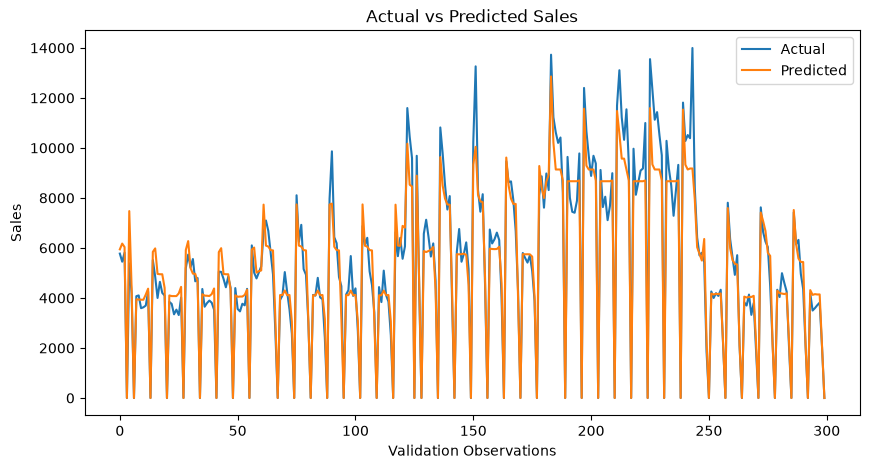

In [213]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    y_valid.values[:300],
    label="Actual"
)

plt.plot(
    y_pred[:300],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Validation Observations")
plt.ylabel("Sales")
plt.legend()
plt.show()

### Actual vs Predicted Sales

The Actual vs Predicted plot shows that the Random Forest model captures the overall sales pattern reasonably well.

The model follows the general movement of actual sales, particularly during normal sales periods and zero-sales observations.

However, some high-sales peaks are underpredicted. This indicates that the model has difficulty capturing some extreme sales values, which also contributes to the higher RMSE compared with MAE.

Overall, this Random Forest model provides a useful baseline for further model improvement.

In [214]:
rf_model_trained = rf_pipeline.named_steps["model"]

importance = rf_model_trained.feature_importances_

print("Number of feature importances:", len(importance))

Number of feature importances: 39


In [215]:
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(len(feature_names))

39


In [216]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
2,num__Open,0.509205
5,num__CompetitionDistance,0.087207
3,num__Promo,0.078286
0,num__Store,0.069853
6,num__CompetitionOpenSinceMonth,0.031411
7,num__CompetitionOpenSinceYear,0.029785
1,num__DayOfWeek,0.028944
9,num__Promo2SinceWeek,0.017119
14,num__WeekOfYear,0.015198
27,cat__StoreType_b,0.015042


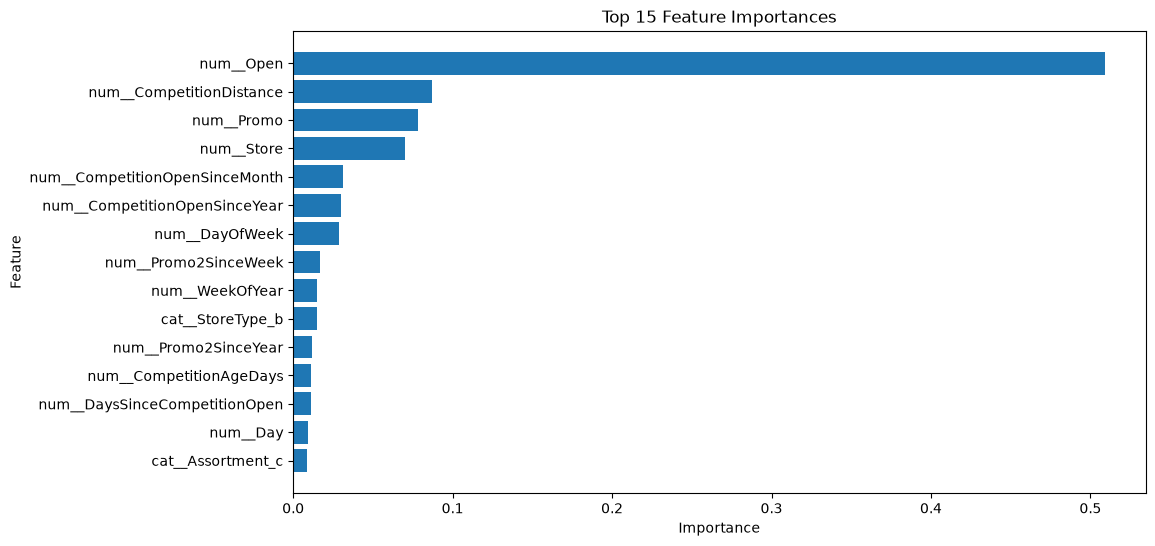

In [217]:
plt.figure(figsize=(11, 6))

plt.barh(
    feature_importance_df["Feature"].head(15)[::-1],
    feature_importance_df["Importance"].head(15)[::-1]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance Analysis

Feature importance from the Random Forest model shows that `Open` is the most important feature for predicting sales.

Other important features include `CompetitionDistance`, `Promo`, `Store`, competition opening information, and time-related features such as `DayOfWeek` and `WeekOfYear`.

The high importance of `Open` is expected because closed stores generally have zero sales in the Rossmann dataset.

Promotion-related features also contribute substantially to the model, which is consistent with the EDA findings where promotional days were associated with higher average sales.

Feature importance indicates how useful features were for the trained Random Forest model. It does not establish causality between a feature and sales.

In [218]:
residuals = y_valid.values - y_pred

In [219]:
print("Mean residual:", residuals.mean())
print("Std residual :", residuals.std())

Mean residual: 205.1073987721814
Std residual : 1240.039038556083


In [220]:
lower_error = np.percentile(residuals, 2.5)
upper_error = np.percentile(residuals, 97.5)

print("Lower error:", lower_error)
print("Upper error:", upper_error)

Lower error: -1953.259983476773
Upper error: 3182.227962310693


In [221]:
prediction_results = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": y_pred
})

prediction_results["Lower_95"] = (
    prediction_results["Predicted"] + lower_error
).clip(lower=0)

prediction_results["Upper_95"] = (
    prediction_results["Predicted"] + upper_error
)

prediction_results.head(10)

,Actual,Predicted,Lower_95,Upper_95
0,5774,5943.617045,3990.357061,9125.845007
1,5450,6174.810190,4221.550207,9357.038152
2,5809,6035.853192,4082.593209,9218.081154
3,0,0.000000,0.000000,3182.227962
4,5384,7473.863495,5520.603511,10656.091457
5,4183,4395.105013,2441.845029,7577.332975
6,0,0.000000,0.000000,3182.227962
7,4071,3945.062104,1991.802120,7127.290066
8,4102,3936.494734,1983.234750,7118.722696
9,3591,3929.694953,1976.434970,7111.922916


#Coverage check

In [222]:
coverage = (
    (prediction_results["Actual"] >= prediction_results["Lower_95"]) &
    (prediction_results["Actual"] <= prediction_results["Upper_95"])
).mean() * 100

print(f"Prediction interval coverage: {coverage:.2f}%")

Prediction interval coverage: 95.00%


### Prediction Interval

A residual-based prediction interval was calculated to estimate the uncertainty around Random Forest sales predictions.

The interval was constructed using the 2.5th and 97.5th percentiles of validation residuals.

This provides an approximate 95% prediction interval. The actual coverage is evaluated on the validation dataset, and the interval should not be interpreted as a guaranteed statistical confidence interval.

### Prediction Interval Coverage Result

The residual-based prediction interval achieved approximately 95.00% coverage on the validation dataset.

This means that approximately 95% of the observed validation sales values fell within the estimated prediction interval.

The interval is an approximate residual-based interval and should not be interpreted as a guaranteed statistical 95% confidence interval.

#Model Comparison

In [223]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [224]:
gb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

In [225]:
OneHotEncoder(handle_unknown="ignore", sparse_output=False)

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [226]:
import joblib
from datetime import datetime

In [227]:
timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")
model_filename = f"rossmann_rf_{timestamp}.pkl"

print(model_filename)

rossmann_rf_01-10-2026-14-31-51.pkl


In [228]:
joblib.dump(rf_pipeline, model_filename)

print("Model saved successfully:", model_filename)

Model saved successfully: rossmann_rf_01-10-2026-14-31-51.pkl


In [229]:
import os

print("File exists:", os.path.exists(model_filename))
print("File size:", os.path.getsize(model_filename) / (1024 * 1024), "MB")

File exists: True
File size: 680.7860898971558 MB


In [230]:
loaded_model = joblib.load(model_filename)

print("Model loaded successfully!")

Model loaded successfully!


In [231]:
test_prediction = loaded_model.predict(
    X_valid_model.iloc[:5]
)

print(test_prediction)

[5943.61704489 6174.81019001 6035.85319218    0.         7473.86349461]


In [232]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.1


In [234]:
import mlflow
import os

print("Environment URI:", os.environ.get("MLFLOW_TRACKING_URI"))
print("MLflow URI:", mlflow.get_tracking_uri())

Environment URI: None
MLflow URI: sqlite:///C:/Users/Anish%20kumar%20tiwari/anaconda3/Scripts/mlflow.db


In [235]:
from pathlib import Path
import mlflow

# Current Jupyter project folder in mlruns folder
tracking_dir = Path.cwd() / "mlruns"

# Windows path ko proper URI mein convert 
tracking_uri = tracking_dir.as_uri()

mlflow.set_tracking_uri(tracking_uri)

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: file:///C:/Users/Anish%20kumar%20tiwari/anaconda3/Scripts/mlruns


#Experiment creation

In [237]:
from pathlib import Path
import mlflow

# Project folder mein MLflow database 
mlflow_db = Path.cwd() / "mlflow.db"

tracking_uri = "sqlite:///" + mlflow_db.as_posix()

mlflow.set_tracking_uri(tracking_uri)

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

MLflow Tracking URI:
sqlite:///C:/Users/Anish kumar tiwari/anaconda3/Scripts/mlflow.db


In [238]:
mlflow.set_experiment("Rossmann_Sales_Forecasting")

print("Experiment ready ✅")

2026/10/01 14:38:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/01 14:38:33 INFO mlflow.store.db.utils: Updating database tables
2026/10/01 14:38:34 INFO mlflow.tracking.fluent: Experiment with name 'Rossmann_Sales_Forecasting' does not exist. Creating a new experiment.


Experiment ready ✅


In [239]:
import os
print("Database exists:", mlflow_db.exists())
print("Database path:", mlflow_db)

Database exists: True
Database path: C:\Users\Anish kumar tiwari\anaconda3\Scripts\mlflow.db


In [241]:
with mlflow.start_run(run_name="RandomForest_Baseline"):

    # Model parameters
    mlflow.log_param("model", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 20)
    mlflow.log_param("random_state", 42)

    # Validation metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)

    # Existing trained model
    model_info = mlflow.sklearn.log_model(
        sk_model=rf_pipeline,
        name="rossmann_random_forest",
        skops_trusted_types=[
            "numpy.dtype",
            "sklearn.tree._tree.Tree"
        ]
    )

    print("Run ID:", mlflow.active_run().info.run_id)
    print("Model URI:", model_info.model_uri)

Run ID: 42440cac0574422f804292986d42f35e
Model URI: models:/m-0b43ed77a06a4aecbd8316f6b792f146


In [242]:
import mlflow
loaded_mlflow_model = mlflow.sklearn.load_model(
    "models:/m-0b43ed77a06a4aecbd8316f6b792f146"
)
print("MLflow model loaded successfully ✅")

MLflow model loaded successfully ✅


In [243]:
test_pred = loaded_mlflow_model.predict(X_valid_model.iloc[:5])
print("Predictions:")
print(test_pred)

Predictions:
[5943.61704489 6174.81019001 6035.85319218    0.         7473.86349461]


#Rossmann Time Series Prepare

In [244]:
# Store 1 ki sales time series

lstm_data = train_merged[
    train_merged["Store"] == 1
][["Date", "Sales"]].copy()

# Date ko datetime mein convert
lstm_data["Date"] = pd.to_datetime(lstm_data["Date"])

# Date ke according sort
lstm_data = lstm_data.sort_values("Date").reset_index(drop=True)

print("Shape:", lstm_data.shape)
print(lstm_data.head())
print(lstm_data.tail())

Shape: (942, 2)
        Date  Sales
0 2013-01-01      0
1 2013-01-02   5530
2 2013-01-03   4327
3 2013-01-04   4486
4 2013-01-05   4997
          Date  Sales
937 2015-07-27   6102
938 2015-07-28   5011
939 2015-07-29   4782
940 2015-07-30   5020
941 2015-07-31   5263


In [245]:
date_range = pd.date_range(
    start=lstm_data["Date"].min(),
    end=lstm_data["Date"].max(),
    freq="D"
)

print("Expected days:", len(date_range))
print("Actual rows:", len(lstm_data))
print("Missing dates:", len(date_range) - len(lstm_data))

Expected days: 942
Actual rows: 942
Missing dates: 0


#Sales time-series plot

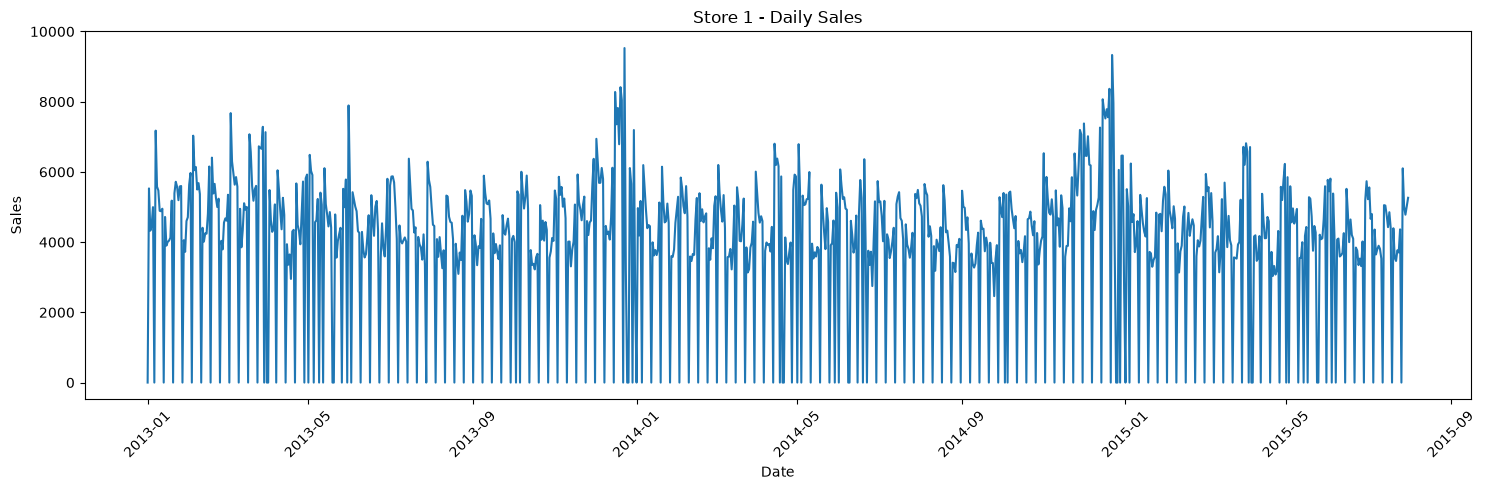

In [246]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    lstm_data["Date"],
    lstm_data["Sales"]
)

plt.title("Store 1 - Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Basic statistics

In [247]:
print("Minimum Sales:", lstm_data["Sales"].min())
print("Maximum Sales:", lstm_data["Sales"].max())
print("Average Sales:", lstm_data["Sales"].mean())
print("Median Sales:", lstm_data["Sales"].median())

Minimum Sales: 0
Maximum Sales: 9528
Average Sales: 3945.704883227176
Median Sales: 4373.5


#ADF Stationarity Test

In [248]:
from statsmodels.tsa.stattools import adfuller

sales_series = lstm_data["Sales"]

adf_result = adfuller(sales_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.3681043681684955
p-value: 0.0003378834614142489


In [249]:
if adf_result[1] < 0.05:
    print("Result: Series is likely stationary ✅")
else:
    print("Result: Series is likely non-stationary ❌")

Result: Series is likely stationary ✅


#ACF & PACF plot

<Figure size 1200x500 with 0 Axes>

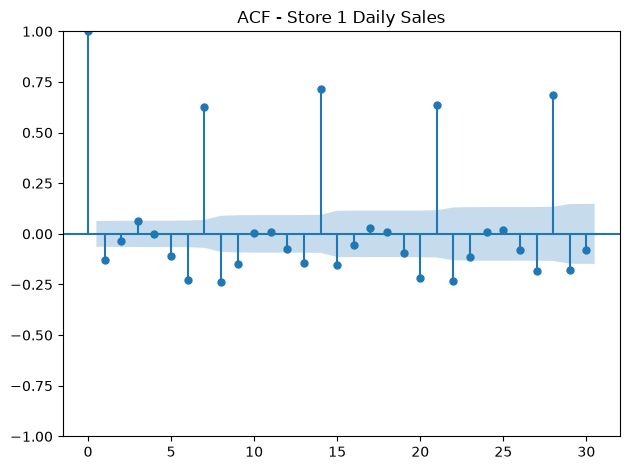

In [250]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    lstm_data["Sales"],
    lags=30
)

plt.title("ACF - Store 1 Daily Sales")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

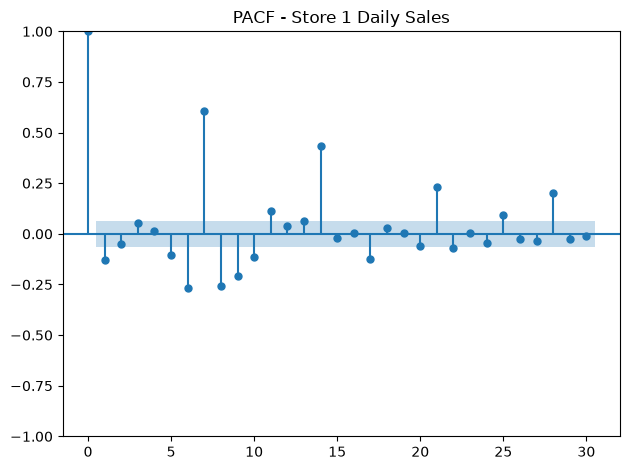

In [251]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(
    lstm_data["Sales"],
    lags=30,
    method="ywm"
)

plt.title("PACF - Store 1 Daily Sales")
plt.tight_layout()
plt.show()

#Train/Test Split

In [252]:
# Chronological split

split_date = pd.Timestamp("2015-06-01")

lstm_train = lstm_data[
    lstm_data["Date"] < split_date
].copy()

lstm_valid = lstm_data[
    lstm_data["Date"] >= split_date
].copy()

print("Training shape:", lstm_train.shape)
print("Validation shape:", lstm_valid.shape)

print("\nTraining period:")
print(lstm_train["Date"].min(), "to", lstm_train["Date"].max())

print("\nValidation period:")
print(lstm_valid["Date"].min(), "to", lstm_valid["Date"].max())

Training shape: (881, 2)
Validation shape: (61, 2)

Training period:
2013-01-01 00:00:00 to 2015-05-31 00:00:00

Validation period:
2015-06-01 00:00:00 to 2015-07-31 00:00:00


#Scaling

In [253]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

# Training data par scaler fit
train_sales_scaled = scaler.fit_transform(
    lstm_train[["Sales"]]
)

# Validation data ko same scaler se transform
valid_sales_scaled = scaler.transform(
    lstm_valid[["Sales"]]
)

print("Training scaled shape:", train_sales_scaled.shape)
print("Validation scaled shape:", valid_sales_scaled.shape)

print("\nTraining scaled min:", train_sales_scaled.min())
print("Training scaled max:", train_sales_scaled.max())

Training scaled shape: (881, 1)
Validation scaled shape: (61, 1)

Training scaled min: -1.0
Training scaled max: 1.0


#Sliding Window

#Training windows

In [254]:
import numpy as np

window_size = 30

X_train_lstm = []
y_train_lstm = []

for i in range(window_size, len(train_sales_scaled)):
    X_train_lstm.append(
        train_sales_scaled[i-window_size:i, 0]
    )
    y_train_lstm.append(
        train_sales_scaled[i, 0]
    )

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

print("X_train shape:", X_train_lstm.shape)
print("y_train shape:", y_train_lstm.shape)

X_train shape: (851, 30)
y_train shape: (851,)


#LSTM INPUT SHAPE

In [255]:
X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

print("Final X_train shape:", X_train_lstm.shape)
print("Final y_train shape:", y_train_lstm.shape)

Final X_train shape: (851, 30, 1)
Final y_train shape: (851,)


#Validation Sliding Window

In [256]:
# Last 30 training days + complete validation data
validation_input = np.concatenate([
    train_sales_scaled[-window_size:],
    valid_sales_scaled
])

X_valid_lstm = []
y_valid_lstm = []

for i in range(window_size, len(validation_input)):
    X_valid_lstm.append(
        validation_input[i-window_size:i, 0]
    )
    y_valid_lstm.append(
        validation_input[i, 0]
    )

X_valid_lstm = np.array(X_valid_lstm)
y_valid_lstm = np.array(y_valid_lstm)

# LSTM expects 3D input
X_valid_lstm = X_valid_lstm.reshape(
    X_valid_lstm.shape[0],
    X_valid_lstm.shape[1],
    1
)

print("X_valid shape:", X_valid_lstm.shape)
print("y_valid shape:", y_valid_lstm.shape)

X_valid shape: (61, 30, 1)
y_valid shape: (61,)


In [260]:
%pip install tensorflow

   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/384.1 MB 5.7 MB/s eta 0:01:08
   ---------------------------------------- 2.1/384.1 MB 6.1 MB/s eta 0:01:03
   ---------------------------------------- 3.4/384.1 MB 6.0 MB/s eta 0:01:04
   ---------------------------------------- 4.5/384.1 MB 5.8 MB/s eta 0:01:06
    --------------------------------------- 5.8/384.1 MB 5.9 MB/s eta 0:01:04
    --------------------------------------- 7.1/384.1 MB 6.0 MB/s eta 0:01:03
    --------------------------------------- 8.4/384.1 MB 6.1 MB/s eta 0:01:03
   - -------------------------------------- 9.7/384.1 MB 6.0 MB/s eta 0:01:03
   - -------------------------------------- 11.0/384.1 MB 6.1 MB/s eta 0:01:02
   - -------------------------------------- 12.1/384.1 MB 6.0 MB/s eta 0:01:02
   - -------------------------------------- 13.4/384.1 MB 6.0 MB/s eta 0:01:02
   - -------------------------------------- 14.7/384.1 MB 6.0 MB/s e

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [262]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


In [263]:
print("TensorFlow is working ✅")

TensorFlow is working ✅


#2-Layer LSTM Model

In [264]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 1)),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

C:\Users\Anish kumar tiwari\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [265]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid_lstm, y_valid_lstm),
    verbose=1
)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 0.1859 - val_loss: 0.1323
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1818 - val_loss: 0.1306
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1808 - val_loss: 0.1290
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1800 - val_loss: 0.1273
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1790 - val_loss: 0.1252
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1777 - val_loss: 0.1223
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1769 - val_loss: 0.1223
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1750 - val_loss: 0.1161
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1757 - val_loss: 0.1219
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1727 - val_loss: 0.1153
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1739 - val_loss: 0.1199
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.

#LSTM PREDICTION

In [266]:
# Predict on validation data
valid_pred_scaled = lstm_model.predict(X_valid_lstm)

print("Scaled prediction shape:", valid_pred_scaled.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 460ms/step
Scaled prediction shape: (61, 1)


In [267]:
# Convert predictions back to original Sales scale
valid_pred = scaler.inverse_transform(valid_pred_scaled)

# Actual validation sales
actual_valid = scaler.inverse_transform(
    y_valid_lstm.reshape(-1, 1)
)

print("First 10 actual sales:")
print(actual_valid[:10].flatten())

print("\nFirst 10 predicted sales:")
print(valid_pred[:10].flatten())

First 10 actual sales:
[5774. 5450. 5809.    0. 5384. 4183.    0. 4071. 4102. 3591.]

First 10 predicted sales:
[6174.062  3883.6135 4125.1343 2649.1384 4984.7207 4281.8374 4487.347
 5309.32   4892.534  4530.377 ]


#MAE & RMSE

In [268]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lstm = mean_absolute_error(
    actual_valid.flatten(),
    valid_pred.flatten()
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        actual_valid.flatten(),
        valid_pred.flatten()
    )
)

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 941.5362741439069
LSTM RMSE: 1279.5246009615923


#ACTUAL VS PREDICTED GRAPH

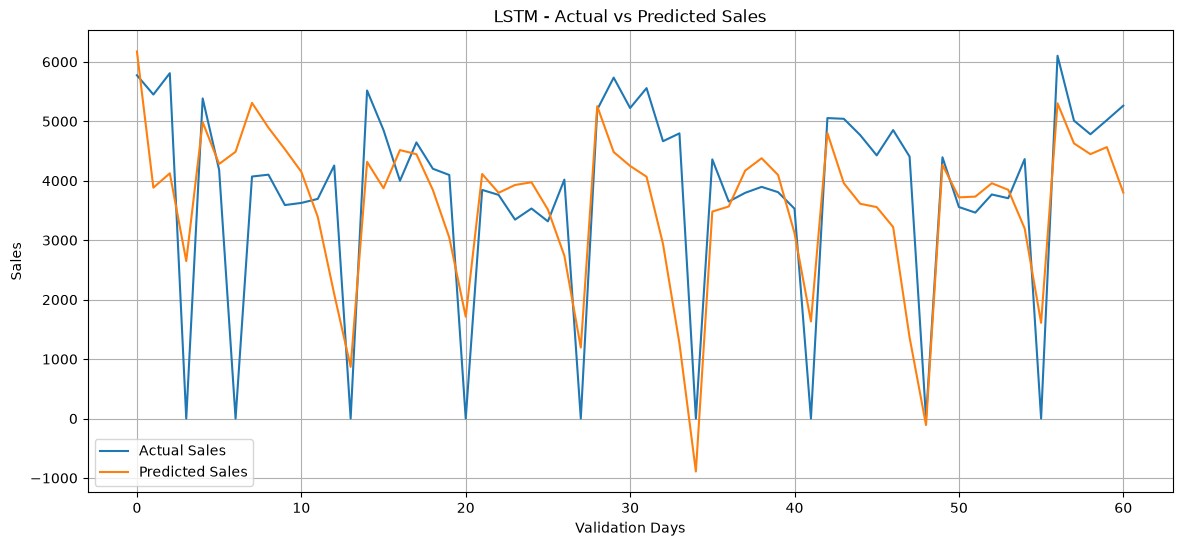

In [269]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    actual_valid.flatten(),
    label="Actual Sales"
)

plt.plot(
    valid_pred.flatten(),
    label="Predicted Sales"
)

plt.title("LSTM - Actual vs Predicted Sales")
plt.xlabel("Validation Days")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [270]:
Dense(1, activation="relu")

<Dense name=dense_1, built=False>

In [271]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lstm = mean_absolute_error(
    actual_valid.flatten(),
    valid_pred.flatten()
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        actual_valid.flatten(),
        valid_pred.flatten()
    )
)

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 941.5362741439069
LSTM RMSE: 1279.5246009615923


#Features prepare

In [272]:
# Store 1 data
lstm_feature_data = train_merged[
    train_merged["Store"] == 1
].copy()

lstm_feature_data["Date"] = pd.to_datetime(
    lstm_feature_data["Date"]
)

lstm_feature_data = lstm_feature_data.sort_values(
    "Date"
).reset_index(drop=True)

# Convert StateHoliday into numeric values
holiday_map = {
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
}

lstm_feature_data["StateHolidayCode"] = (
    lstm_feature_data["StateHoliday"]
    .astype(str)
    .map(holiday_map)
    .fillna(0)
)

# Select features
lstm_features = [
    "Sales",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday",
    "StateHolidayCode"
]

lstm_feature_data = lstm_feature_data[
    ["Date"] + lstm_features
]

print("Shape:", lstm_feature_data.shape)
print("\nColumns:")
print(lstm_feature_data.columns.tolist())

print("\nFirst 5 rows:")
display(lstm_feature_data.head())

Shape: (942, 7)

Columns:
['Date', 'Sales', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'StateHolidayCode']

First 5 rows:


,Date,Sales,DayOfWeek,Open,Promo,SchoolHoliday,StateHolidayCode
0,2013-01-01,0,2,0,0,1,1
1,2013-01-02,5530,3,1,0,1,0
2,2013-01-03,4327,4,1,0,1,0
3,2013-01-04,4486,5,1,0,1,0
4,2013-01-05,4997,6,1,0,1,0


#Chronological split

In [273]:
split_date = pd.Timestamp("2015-06-01")

lstm_feature_train = lstm_feature_data[
    lstm_feature_data["Date"] < split_date
].copy()

lstm_feature_valid = lstm_feature_data[
    lstm_feature_data["Date"] >= split_date
].copy()

print("Training shape:", lstm_feature_train.shape)
print("Validation shape:", lstm_feature_valid.shape)

print(
    "\nTraining dates:",
    lstm_feature_train["Date"].min(),
    "to",
    lstm_feature_train["Date"].max()
)

print(
    "Validation dates:",
    lstm_feature_valid["Date"].min(),
    "to",
    lstm_feature_valid["Date"].max()
)

Training shape: (881, 7)
Validation shape: (61, 7)

Training dates: 2013-01-01 00:00:00 to 2015-05-31 00:00:00
Validation dates: 2015-06-01 00:00:00 to 2015-07-31 00:00:00


In [274]:
from sklearn.preprocessing import MinMaxScaler

# Features that will be used by LSTM
feature_columns = [
    "Sales",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday",
    "StateHolidayCode"
]

# Create scaler
feature_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit only on training data
train_features_scaled = feature_scaler.fit_transform(
    lstm_feature_train[feature_columns]
)

# Transform validation using the same scaler
valid_features_scaled = feature_scaler.transform(
    lstm_feature_valid[feature_columns]
)

print("Training scaled shape:", train_features_scaled.shape)
print("Validation scaled shape:", valid_features_scaled.shape)

print("\nTraining min:", train_features_scaled.min(axis=0))
print("Training max:", train_features_scaled.max(axis=0))

Training scaled shape: (881, 6)
Validation scaled shape: (61, 6)

Training min: [-1. -1. -1. -1. -1. -1.]
Training max: [1. 1. 1. 1. 1. 1.]


#30-day sliding window

In [275]:
window_size = 30

X_train_feature_lstm = []
y_train_feature_lstm = []

for i in range(window_size, len(train_features_scaled)):
    X_train_feature_lstm.append(
        train_features_scaled[i-window_size:i, :]
    )
    
    # Sales is the first column
    y_train_feature_lstm.append(
        train_features_scaled[i, 0]
    )

X_train_feature_lstm = np.array(X_train_feature_lstm)
y_train_feature_lstm = np.array(y_train_feature_lstm)

print("X_train shape:", X_train_feature_lstm.shape)
print("y_train shape:", y_train_feature_lstm.shape)

X_train shape: (851, 30, 6)
y_train shape: (851,)


In [276]:
# Combine last 30 training days with validation data
validation_input = np.concatenate([
    train_features_scaled[-window_size:],
    valid_features_scaled
])

X_valid_feature_lstm = []
y_valid_feature_lstm = []

for i in range(window_size, len(validation_input)):
    X_valid_feature_lstm.append(
        validation_input[i-window_size:i, :]
    )
    
    # Sales is the first column
    y_valid_feature_lstm.append(
        validation_input[i, 0]
    )

X_valid_feature_lstm = np.array(X_valid_feature_lstm)
y_valid_feature_lstm = np.array(y_valid_feature_lstm)

print("X_valid shape:", X_valid_feature_lstm.shape)
print("y_valid shape:", y_valid_feature_lstm.shape)

X_valid shape: (61, 30, 6)
y_valid shape: (61,)


#Multivariate LSTM Model

In [277]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

feature_lstm_model = Sequential([
    Input(shape=(30, 6)),
    
    LSTM(64, return_sequences=True),
    LSTM(32),
    
    Dense(1, activation="relu")
])

feature_lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

feature_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 30, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [278]:
feature_history = feature_lstm_model.fit(
    X_train_feature_lstm,
    y_train_feature_lstm,
    epochs=30,
    batch_size=32,
    validation_data=(
        X_valid_feature_lstm,
        y_valid_feature_lstm
    ),
    verbose=1
)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - loss: 0.2121 - val_loss: 0.1720
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2115 - val_loss: 0.1720
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.

In [279]:
# Predict validation data
feature_pred_scaled = feature_lstm_model.predict(
    X_valid_feature_lstm
)

print("Prediction shape:", feature_pred_scaled.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
Prediction shape: (61, 1)


In [280]:
# Create empty array for inverse scaling
pred_for_inverse = np.zeros(
    (len(feature_pred_scaled), len(feature_columns))
)

actual_for_inverse = np.zeros(
    (len(y_valid_feature_lstm), len(feature_columns))
)

# Sales is column 0
pred_for_inverse[:, 0] = feature_pred_scaled.flatten()
actual_for_inverse[:, 0] = y_valid_feature_lstm

# Convert back to original scale
feature_pred_original = feature_scaler.inverse_transform(
    pred_for_inverse
)[:, 0]

actual_feature_original = feature_scaler.inverse_transform(
    actual_for_inverse
)[:, 0]

print("First 10 actual sales:")
print(actual_feature_original[:10])

print("\nFirst 10 predicted sales:")
print(feature_pred_original[:10])

First 10 actual sales:
[5774. 5450. 5809.    0. 5384. 4183.    0. 4071. 4102. 3591.]

First 10 predicted sales:
[4764. 4764. 4764. 4764. 4764. 4764. 4764. 4764. 4764. 4764.]


In [281]:
MinMaxScaler(feature_range=(-1, 1))

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(-1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


#Improved LSTM

In [282]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

feature_lstm_model = Sequential([
    Input(shape=(30, 6)),
    
    LSTM(64, return_sequences=True),
    LSTM(32),
    
    Dense(1)
])

feature_lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

feature_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 30, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [283]:
feature_history = feature_lstm_model.fit(
    X_train_feature_lstm,
    y_train_feature_lstm,
    epochs=30,
    batch_size=32,
    validation_data=(
        X_valid_feature_lstm,
        y_valid_feature_lstm
    ),
    verbose=1
)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - loss: 0.1846 - val_loss: 0.1163
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1688 - val_loss: 0.1079
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1587 - val_loss: 0.0983
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1441 - val_loss: 0.0868
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1270 - val_loss: 0.0688
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1085 - val_loss: 0.0582
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0943 - val_loss: 0.0483
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0842 - val_loss: 0.0433
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0774 - val_loss: 0.0404
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0728 - val_loss: 0.0378
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0685 - val_loss: 0.0355
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.

In [284]:
feature_pred_scaled = feature_lstm_model.predict(
    X_valid_feature_lstm
)

print("Prediction shape:", feature_pred_scaled.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step
Prediction shape: (61, 1)


In [285]:
pred_for_inverse = np.zeros(
    (len(feature_pred_scaled), len(feature_columns))
)

actual_for_inverse = np.zeros(
    (len(y_valid_feature_lstm), len(feature_columns))
)

pred_for_inverse[:, 0] = feature_pred_scaled.flatten()
actual_for_inverse[:, 0] = y_valid_feature_lstm

feature_pred_original = feature_scaler.inverse_transform(
    pred_for_inverse
)[:, 0]

actual_feature_original = feature_scaler.inverse_transform(
    actual_for_inverse
)[:, 0]

print("First 10 actual sales:")
print(actual_feature_original[:10])

print("\nFirst 10 predicted sales:")
print(feature_pred_original[:10])

First 10 actual sales:
[5774. 5450. 5809.    0. 5384. 4183.    0. 4071. 4102. 3591.]

First 10 predicted sales:
[5835.40297669 5143.97933811 4922.79677828 4594.93109433 6042.79367924
 5329.02784413  729.83898139 4383.26011983 4044.04767501 3679.33703434]


#Calculate MAE & RMSE

In [286]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_feature_lstm = mean_absolute_error(
    actual_feature_original,
    feature_pred_original
)

rmse_feature_lstm = np.sqrt(
    mean_squared_error(
        actual_feature_original,
        feature_pred_original
    )
)

print("Feature LSTM MAE:", mae_feature_lstm)
print("Feature LSTM RMSE:", rmse_feature_lstm)

Feature LSTM MAE: 453.61805462348656
Feature LSTM RMSE: 762.5300770787552


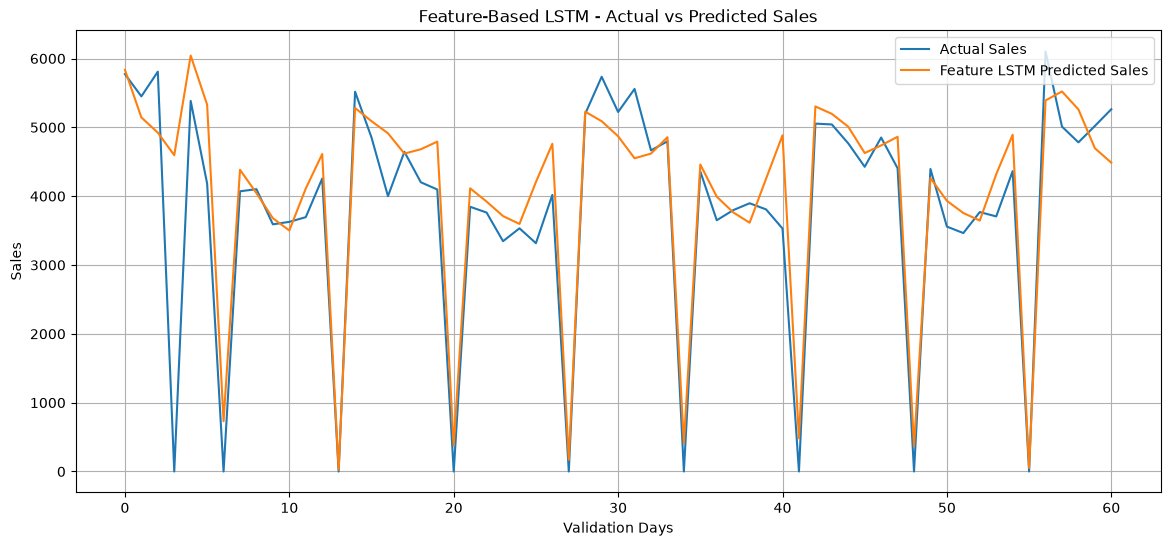

In [287]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    actual_feature_original,
    label="Actual Sales"
)

plt.plot(
    feature_pred_original,
    label="Feature LSTM Predicted Sales"
)

plt.title("Feature-Based LSTM - Actual vs Predicted Sales")
plt.xlabel("Validation Days")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [288]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_feature_lstm = mean_absolute_error(
    actual_feature_original,
    feature_pred_original
)

rmse_feature_lstm = np.sqrt(
    mean_squared_error(
        actual_feature_original,
        feature_pred_original
    )
)

print("Feature LSTM MAE:", mae_feature_lstm)
print("Feature LSTM RMSE:", rmse_feature_lstm)

Feature LSTM MAE: 453.61805462348656
Feature LSTM RMSE: 762.5300770787552


#Training Loss Graph

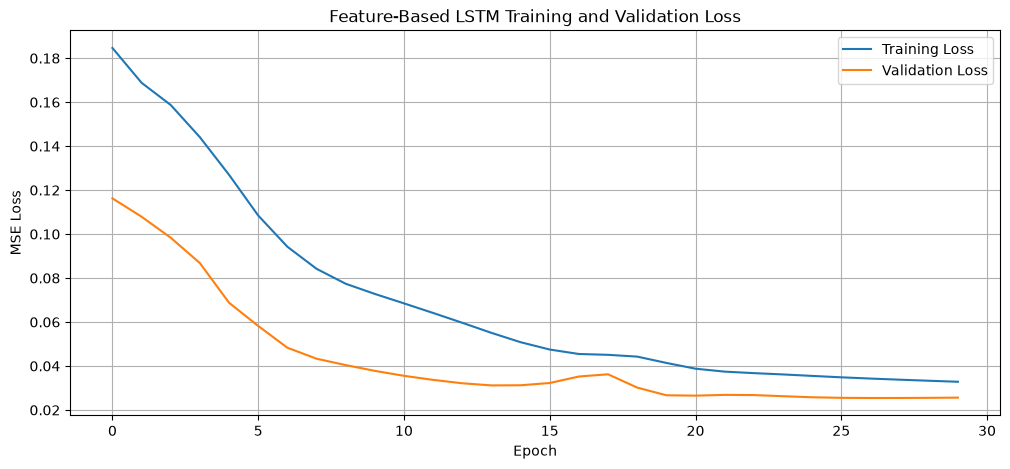

In [289]:
plt.figure(figsize=(12, 5))

plt.plot(
    feature_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    feature_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Feature-Based LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [290]:
from pathlib import Path
import joblib

# Create models folder
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save LSTM model
lstm_model_path = models_dir / "rossmann_feature_lstm.keras"

feature_lstm_model.save(lstm_model_path)

print("LSTM model saved at:", lstm_model_path)

LSTM model saved at: models\rossmann_feature_lstm.keras


In [291]:
scaler_path = models_dir / "rossmann_feature_scaler.pkl"

joblib.dump(
    feature_scaler,
    scaler_path
)

print("Scaler saved at:", scaler_path)

Scaler saved at: models\rossmann_feature_scaler.pkl


In [292]:
from tensorflow.keras.models import load_model

loaded_lstm_model = load_model(
    "models/rossmann_feature_lstm.keras"
)

loaded_scaler = joblib.load(
    "models/rossmann_feature_scaler.pkl"
)

print("Model loaded successfully ✅")
print("Scaler loaded successfully ✅")

Model loaded successfully ✅
Scaler loaded successfully ✅


In [293]:
loaded_pred_scaled = loaded_lstm_model.predict(
    X_valid_feature_lstm,
    verbose=0
)

print("Loaded model prediction shape:", loaded_pred_scaled.shape)

Loaded model prediction shape: (61, 1)


In [294]:
prediction_difference = np.max(
    np.abs(
        loaded_pred_scaled.flatten()
        - feature_pred_scaled.flatten()
    )
)

print("Maximum prediction difference:", prediction_difference)

Maximum prediction difference: 0.0


In [295]:
# Store 1 future data
store_1_future = test_merged[
    test_merged["Store"] == 1
].copy()

store_1_future["Date"] = pd.to_datetime(
    store_1_future["Date"]
)

store_1_future = store_1_future.sort_values(
    "Date"
).reset_index(drop=True)

# Convert StateHoliday to numeric
store_1_future["StateHolidayCode"] = (
    store_1_future["StateHoliday"]
    .astype(str)
    .map(holiday_map)
    .fillna(0)
)

# First 42 days = 6 weeks
forecast_future = store_1_future.head(42).copy()

print("Forecast period:")
print(forecast_future["Date"].min())
print("to")
print(forecast_future["Date"].max())

print("\nShape:", forecast_future.shape)

display(
    forecast_future[
        [
            "Date",
            "DayOfWeek",
            "Open",
            "Promo",
            "StateHoliday",
            "SchoolHoliday"
        ]
    ].head()
)

Forecast period:
2015-08-01 00:00:00
to
2015-09-11 00:00:00

Shape: (42, 18)


,Date,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday
0,2015-08-01,6,1.0,0,0,1
1,2015-08-02,7,0.0,0,0,1
2,2015-08-03,1,1.0,1,0,1
3,2015-08-04,2,1.0,1,0,1
4,2015-08-05,3,1.0,1,0,1


In [296]:
# Start with the last 30 days of training data
forecast_history = train_features_scaled[-window_size:].copy()

forecast_predictions_scaled = []

for i in range(len(forecast_future)):
    
    # Last 30 days as model input
    input_sequence = forecast_history[-window_size:]
    
    # Reshape for LSTM
    input_sequence = input_sequence.reshape(1, window_size, 6)
    
    # Predict next day's Sales
    next_sales_scaled = feature_lstm_model.predict(
        input_sequence,
        verbose=0
    )[0, 0]
    
    forecast_predictions_scaled.append(
        next_sales_scaled
    )
    
    # Future day's known features
    future_row = forecast_future.iloc[i]
    
    future_features = np.array([
        next_sales_scaled,
        future_row["DayOfWeek"],
        future_row["Open"],
        future_row["Promo"],
        future_row["SchoolHoliday"],
        future_row["StateHolidayCode"]
    ])
    
    # Add predicted day to history
    forecast_history = np.vstack([
        forecast_history,
        future_features
    ])

print("Forecasts generated:", len(forecast_predictions_scaled))

Forecasts generated: 42


In [297]:
forecast_for_inverse = np.zeros(
    (len(forecast_predictions_scaled), len(feature_columns))
)

forecast_for_inverse[:, 0] = forecast_predictions_scaled

forecast_sales = feature_scaler.inverse_transform(
    forecast_for_inverse
)[:, 0]

# Sales negative nahi ho sakti
forecast_sales = np.maximum(forecast_sales, 0)

print("First 10 forecasted sales:")
print(forecast_sales[:10])

First 10 forecasted sales:
[5835.40297669    0.         3322.89165831 4914.26374264 4550.71026032
 4197.41479629 4297.28110027 4784.21225192 5067.9141283  6367.1640358 ]


In [298]:
forecast_result = forecast_future[
    ["Date", "DayOfWeek", "Open", "Promo",
     "StateHoliday", "SchoolHoliday"]
].copy()

forecast_result["PredictedSales"] = forecast_sales

display(forecast_result.head(10))

,Date,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,PredictedSales
0,2015-08-01,6,1.0,0,0,1,5835.402977
1,2015-08-02,7,0.0,0,0,1,0.000000
2,2015-08-03,1,1.0,1,0,1,3322.891658
3,2015-08-04,2,1.0,1,0,1,4914.263743
4,2015-08-05,3,1.0,1,0,1,4550.710260
5,2015-08-06,4,1.0,1,0,1,4197.414796
6,2015-08-07,5,1.0,1,0,1,4297.281100
7,2015-08-08,6,1.0,0,0,1,4784.212252
8,2015-08-09,7,0.0,0,0,1,5067.914128
9,2015-08-10,1,1.0,0,0,1,6367.164036


In [299]:
# Closed stores should have zero sales
forecast_result.loc[
    forecast_result["Open"] == 0,
    "PredictedSales"
] = 0

display(forecast_result.head(10))

,Date,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,PredictedSales
0,2015-08-01,6,1.0,0,0,1,5835.402977
1,2015-08-02,7,0.0,0,0,1,0.000000
2,2015-08-03,1,1.0,1,0,1,3322.891658
3,2015-08-04,2,1.0,1,0,1,4914.263743
4,2015-08-05,3,1.0,1,0,1,4550.710260
5,2015-08-06,4,1.0,1,0,1,4197.414796
6,2015-08-07,5,1.0,1,0,1,4297.281100
7,2015-08-08,6,1.0,0,0,1,4784.212252
8,2015-08-09,7,0.0,0,0,1,0.000000
9,2015-08-10,1,1.0,0,0,1,6367.164036


In [300]:
customer_data = ml_data.copy()

# Customers is the target
X_customer = customer_data.drop(
    columns=["Customers", "Sales", "Date"]
)

y_customer = customer_data["Customers"]

print("Customer feature shape:", X_customer.shape)
print("Customer target shape:", y_customer.shape)

Customer feature shape: (1017209, 29)
Customer target shape: (1017209,)


#TIME BASED SPLIT

In [302]:
X_customer = customer_data.drop(columns=["Customers", "Sales", "Date"])

In [304]:
# Customer model ke liye time-based split

customer_train_mask = customer_data["Date"] < "2015-06-01"
customer_valid_mask = customer_data["Date"] >= "2015-06-01"

X_customer_train = X_customer.loc[customer_train_mask]
X_customer_valid = X_customer.loc[customer_valid_mask]

y_customer_train = y_customer.loc[customer_train_mask]
y_customer_valid = y_customer.loc[customer_valid_mask]

# Date already X_customer se remove ho chuka hai
X_customer_train_model = X_customer_train.copy()
X_customer_valid_model = X_customer_valid.copy()

print("Customer training:", X_customer_train_model.shape)
print("Customer validation:", X_customer_valid_model.shape)
print("Customer target training:", y_customer_train.shape)
print("Customer target validation:", y_customer_valid.shape)

Customer training: (949194, 29)
Customer validation: (68015, 29)
Customer target training: (949194,)
Customer target validation: (68015,)


In [305]:
customer_numeric_features = [
    col for col in numeric_features
    if col in X_customer_train_model.columns
]

customer_categorical_features = [
    col for col in categorical_features
    if col in X_customer_train_model.columns
]

customer_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            customer_numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            customer_categorical_features
        )
    ]
)

print("Customer preprocessing ready ✅")

Customer preprocessing ready ✅


In [306]:
customer_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

customer_pipeline = Pipeline([
    ("preprocessor", customer_preprocessor),
    ("model", customer_rf)
])

customer_pipeline.fit(
    X_customer_train_model,
    y_customer_train
)

print("Customer model trained successfully ✅")

Customer model trained successfully ✅


#Customer Model MAE & RMSE

In [307]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Customer predictions
customer_pred = customer_pipeline.predict(X_customer_valid_model)

# Metrics
customer_mae = mean_absolute_error(
    y_customer_valid,
    customer_pred
)

customer_rmse = np.sqrt(
    mean_squared_error(
        y_customer_valid,
        customer_pred
    )
)

print("Customer Model Performance")
print("-" * 35)
print("MAE :", customer_mae)
print("RMSE:", customer_rmse)

Customer Model Performance
-----------------------------------
MAE : 56.45120394336226
RMSE: 86.78951432462166


In [308]:
import os
import joblib
from datetime import datetime

# Models folder create karo
os.makedirs("models", exist_ok=True)

# Timestamp
timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")

# File name
customer_model_path = f"models/rossmann_customer_rf_{timestamp}.pkl"

# Save model
joblib.dump(
    customer_pipeline,
    customer_model_path
)

print("Customer model saved successfully ✅")
print("File:", customer_model_path)

Customer model saved successfully ✅
File: models/rossmann_customer_rf_01-10-2026-15-40-57.pkl


In [309]:
# Saved model reload
loaded_customer_model = joblib.load(customer_model_path)

# Test prediction
loaded_customer_pred = loaded_customer_model.predict(
    X_customer_valid_model.iloc[:10]
)

print("Reloaded customer model successfully ✅")
print("Sample predictions:")
print(loaded_customer_pred)

Reloaded customer model successfully ✅
Sample predictions:
[620.51162094 567.38727888 598.80738194   0.         647.7488494
 550.47074968   0.         483.44849697 477.69322069 477.4467533 ]


In [310]:
# Test data ki copy
future_data = test_merged.copy()

# Date ko datetime format mein rakho
future_data["Date"] = pd.to_datetime(future_data["Date"])

print("Future data shape:", future_data.shape)
print("\nDate range:")
print(future_data["Date"].min(), "to", future_data["Date"].max())

print("\nColumns:")
print(future_data.columns.tolist())

Future data shape: (41088, 17)

Date range:
2015-08-01 00:00:00 to 2015-09-17 00:00:00

Columns:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


#Future data mein wahi features create 

In [311]:
# Calendar features
future_data["Year"] = future_data["Date"].dt.year
future_data["Month"] = future_data["Date"].dt.month
future_data["Day"] = future_data["Date"].dt.day
future_data["WeekOfYear"] = future_data["Date"].dt.isocalendar().week.astype(int)

# Weekend
future_data["IsWeekend"] = (
    future_data["DayOfWeek"].isin([6, 7])
).astype(int)

# Month period
future_data["MonthPeriod"] = future_data["Date"].dt.to_period("M").astype(str)

# Holiday
future_data["IsHoliday"] = (
    future_data["StateHoliday"].astype(str) != "0"
).astype(int)

# State holiday before / after
future_data = future_data.sort_values(["Store", "Date"])

future_data["HolidayBefore"] = (
    future_data.groupby("Store")["IsHoliday"]
    .shift(1)
    .fillna(0)
    .astype(int)
)

future_data["HolidayAfter"] = (
    future_data.groupby("Store")["IsHoliday"]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

# Competition open date
future_data["CompetitionOpenDate"] = pd.to_datetime(
    dict(
        year=future_data["CompetitionOpenSinceYear"],
        month=future_data["CompetitionOpenSinceMonth"],
        day=1
    ),
    errors="coerce"
)

# Competition age
future_data["CompetitionAgeDays"] = (
    future_data["Date"] - future_data["CompetitionOpenDate"]
).dt.days

future_data["CompetitionAgeDays"] = (
    future_data["CompetitionAgeDays"]
    .clip(lower=0)
    .fillna(0)
)

# Promo2 active
future_data["Promo2Active"] = (
    future_data["Promo2"] == 1
).astype(int)

# Days since competition opened
future_data["DaysSinceCompetitionOpen"] = (
    future_data["CompetitionAgeDays"]
)

print("Future features created successfully ✅")
print("Shape:", future_data.shape)

Future features created successfully ✅
Shape: (41088, 30)


In [312]:
print("Future data ready:", future_data.shape)

print("\nMissing values:")
print(
    future_data[
        ["CompetitionDistance",
         "CompetitionOpenSinceMonth",
         "CompetitionOpenSinceYear",
         "CompetitionAgeDays",
         "DaysSinceCompetitionOpen"]
    ].isna().sum()
)

Future data ready: (41088, 30)

Missing values:
CompetitionDistance             96
CompetitionOpenSinceMonth    15216
CompetitionOpenSinceYear     15216
CompetitionAgeDays               0
DaysSinceCompetitionOpen         0
dtype: int64


In [313]:
# ==============================
# STEP 33D: FUTURE PREDICTIONS
# ==============================

# Sales model ke required columns
sales_features = [
    col for col in numeric_features + categorical_features
    if col in future_data.columns
]

# Customer model ke required columns
customer_features = [
    col for col in customer_numeric_features + customer_categorical_features
    if col in future_data.columns
]

# Prediction data
X_future_sales = future_data[sales_features].copy()
X_future_customer = future_data[customer_features].copy()

print("Sales input shape:", X_future_sales.shape)
print("Customer input shape:", X_future_customer.shape)

# ------------------------------
# Sales prediction
# ------------------------------
future_sales_pred = rf_pipeline.predict(X_future_sales)

# Store closed hone par sales 0
future_sales_pred[future_data["Open"].values == 0] = 0

# ------------------------------
# Customer prediction
# ------------------------------
future_customer_pred = loaded_customer_model.predict(
    X_future_customer
)

# Store closed hone par customers 0
future_customer_pred[future_data["Open"].values == 0] = 0

# Negative predictions avoid karo
future_sales_pred = np.maximum(future_sales_pred, 0)
future_customer_pred = np.maximum(future_customer_pred, 0)

print("\nPredictions generated successfully ✅")
print("Sales predictions:", len(future_sales_pred))
print("Customer predictions:", len(future_customer_pred))

Sales input shape: (41088, 27)
Customer input shape: (41088, 27)

Predictions generated successfully ✅
Sales predictions: 41088
Customer predictions: 41088


In [314]:
forecast_df = future_data[
    ["Id", "Store", "Date", "DayOfWeek", "Open", "Promo",
     "StateHoliday", "SchoolHoliday"]
].copy()

forecast_df["PredictedSales"] = future_sales_pred
forecast_df["PredictedCustomers"] = future_customer_pred

# Date order
forecast_df = forecast_df.sort_values(
    ["Store", "Date"]
).reset_index(drop=True)

print("Final forecast table created ✅")

display(
    forecast_df.head(10)
)

Final forecast table created ✅


,Id,Store,Date,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,PredictedSales,PredictedCustomers
0,40233,1,2015-08-01,6,1.0,0,0,1,5789.515352,621.884095
1,39377,1,2015-08-02,7,0.0,0,0,1,0.000000,0.000000
2,38521,1,2015-08-03,1,1.0,1,0,1,5945.858193,605.157726
3,37665,1,2015-08-04,2,1.0,1,0,1,6006.681767,562.555837
4,36809,1,2015-08-05,3,1.0,1,0,1,4969.352367,550.094696
5,35953,1,2015-08-06,4,1.0,1,0,1,4956.182096,549.303159
6,35097,1,2015-08-07,5,1.0,1,0,1,4956.182096,549.303159
7,34241,1,2015-08-08,6,1.0,0,0,1,4326.148762,522.234872
8,33385,1,2015-08-09,7,0.0,0,0,1,0.000000,0.000000
9,32529,1,2015-08-10,1,1.0,0,0,1,4113.297327,479.886987


In [315]:
# ==========================================
#  6-WEEK FORECAST SUMMARY
# ==========================================

# Overall forecast
total_sales = forecast_df["PredictedSales"].sum()
total_customers = forecast_df["PredictedCustomers"].sum()

open_days = (forecast_df["Open"] == 1).sum()
closed_days = (forecast_df["Open"] == 0).sum()

print("6-WEEK FORECAST SUMMARY")
print("=" * 40)
print(f"Forecast days       : {len(forecast_df)}")
print(f"Open days           : {open_days}")
print(f"Closed days         : {closed_days}")
print(f"Predicted Sales     : {total_sales:,.2f}")
print(f"Predicted Customers : {total_customers:,.2f}")

6-WEEK FORECAST SUMMARY
Forecast days       : 41088
Open days           : 35104
Closed days         : 5984
Predicted Sales     : 239,498,545.92
Predicted Customers : 25,830,616.91


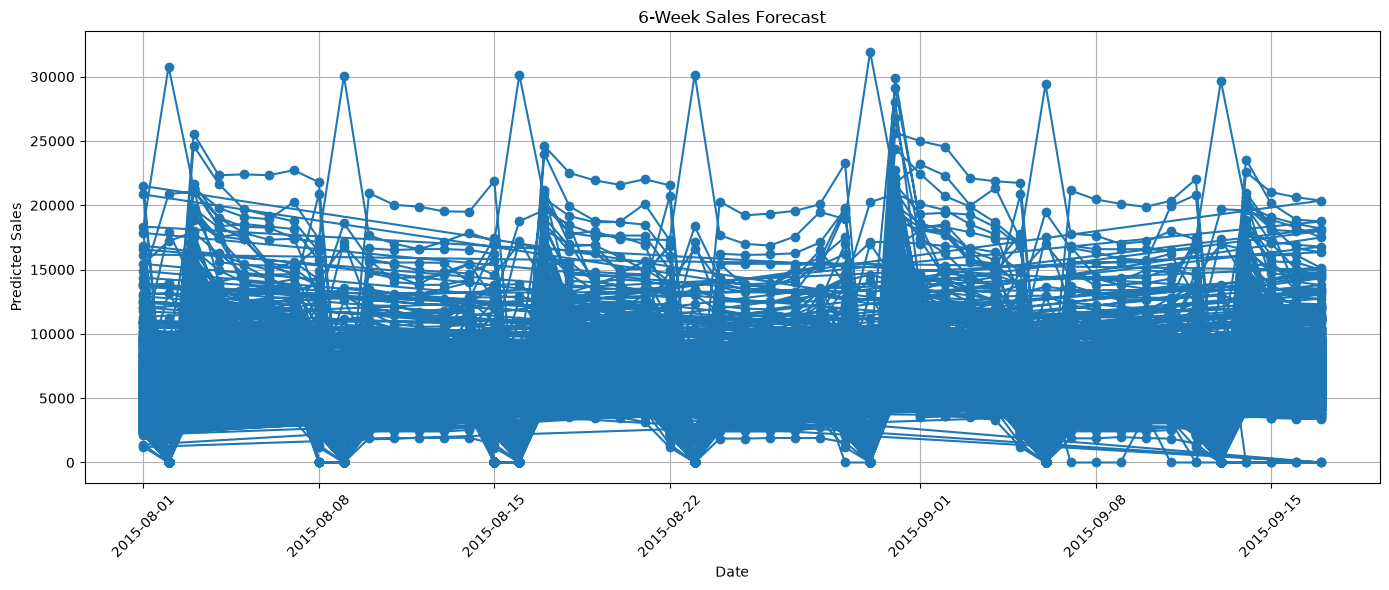

In [316]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["PredictedSales"],
    marker="o"
)

plt.title("6-Week Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

#Customer forecast graph 

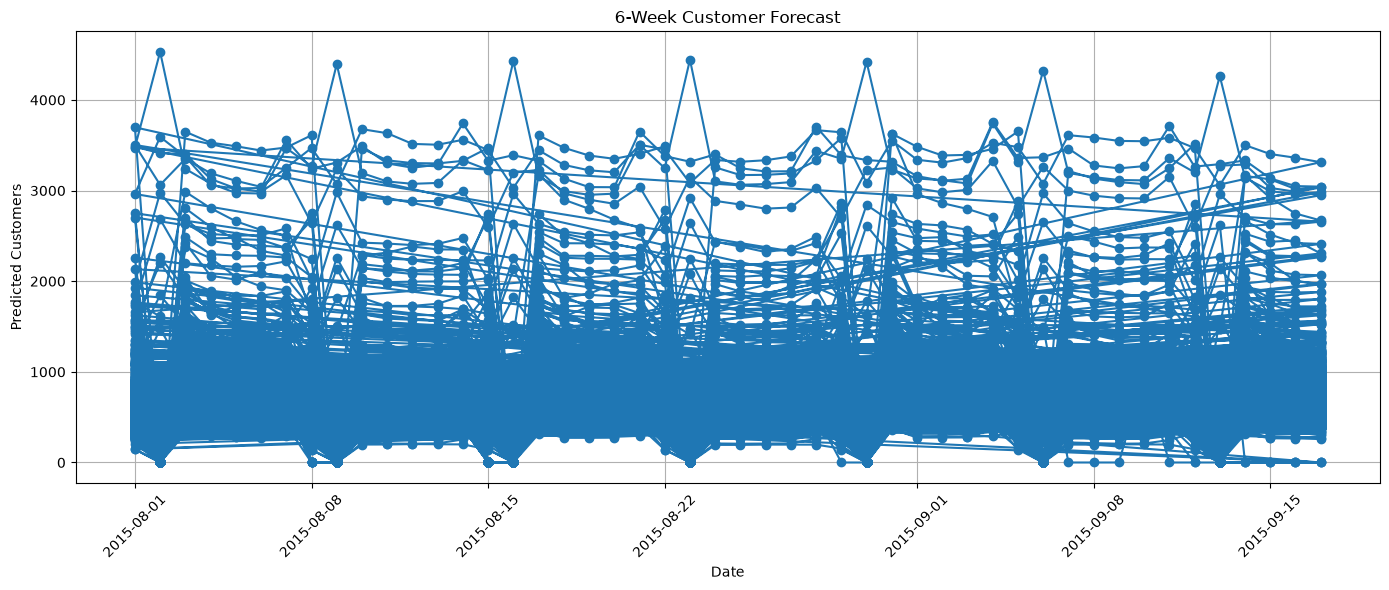

In [317]:
plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["PredictedCustomers"],
    marker="o"
)

plt.title("6-Week Customer Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [318]:
# Store 1 forecast
store_1_forecast = forecast_df[
    forecast_df["Store"] == 1
].copy()

print("Store 1 forecast rows:", len(store_1_forecast))

display(store_1_forecast.head())

Store 1 forecast rows: 48


,Id,Store,Date,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,PredictedSales,PredictedCustomers
0,40233,1,2015-08-01,6,1.0,0,0,1,5789.515352,621.884095
1,39377,1,2015-08-02,7,0.0,0,0,1,0.000000,0.000000
2,38521,1,2015-08-03,1,1.0,1,0,1,5945.858193,605.157726
3,37665,1,2015-08-04,2,1.0,1,0,1,6006.681767,562.555837
4,36809,1,2015-08-05,3,1.0,1,0,1,4969.352367,550.094696


In [319]:
store_1_6week = store_1_forecast.iloc[:42].copy()

print("6-week rows:", len(store_1_6week))

6-week rows: 42


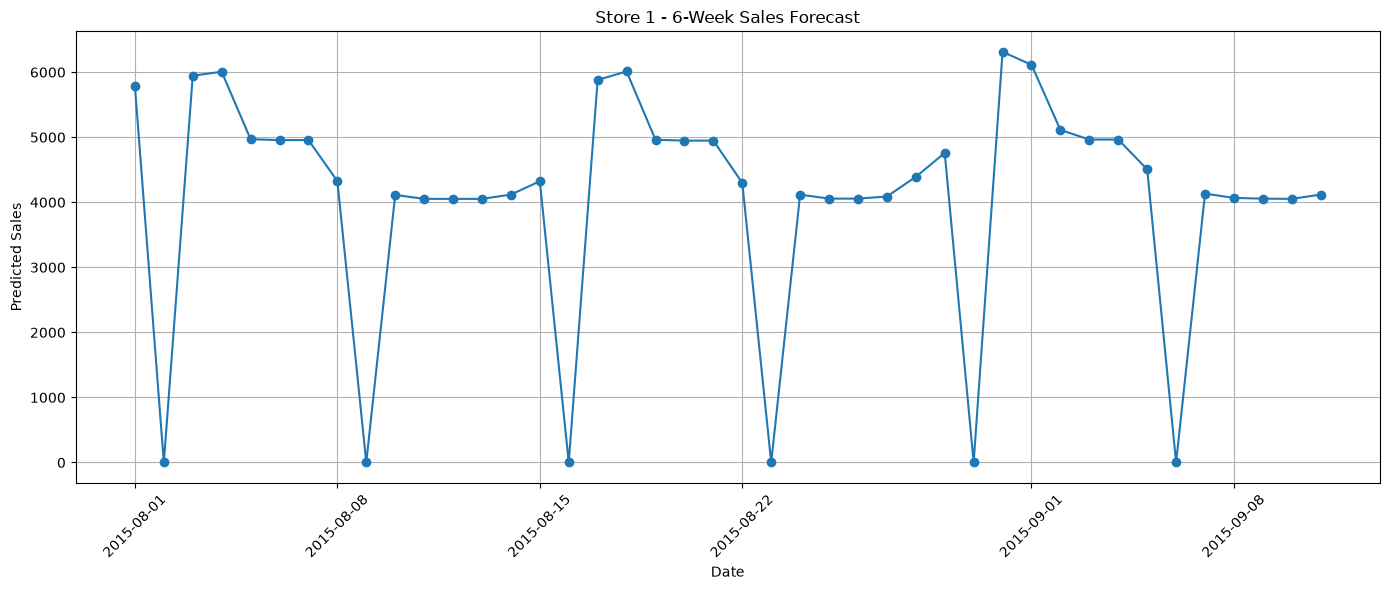

In [320]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    store_1_6week["Date"],
    store_1_6week["PredictedSales"],
    marker="o"
)

plt.title("Store 1 - 6-Week Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

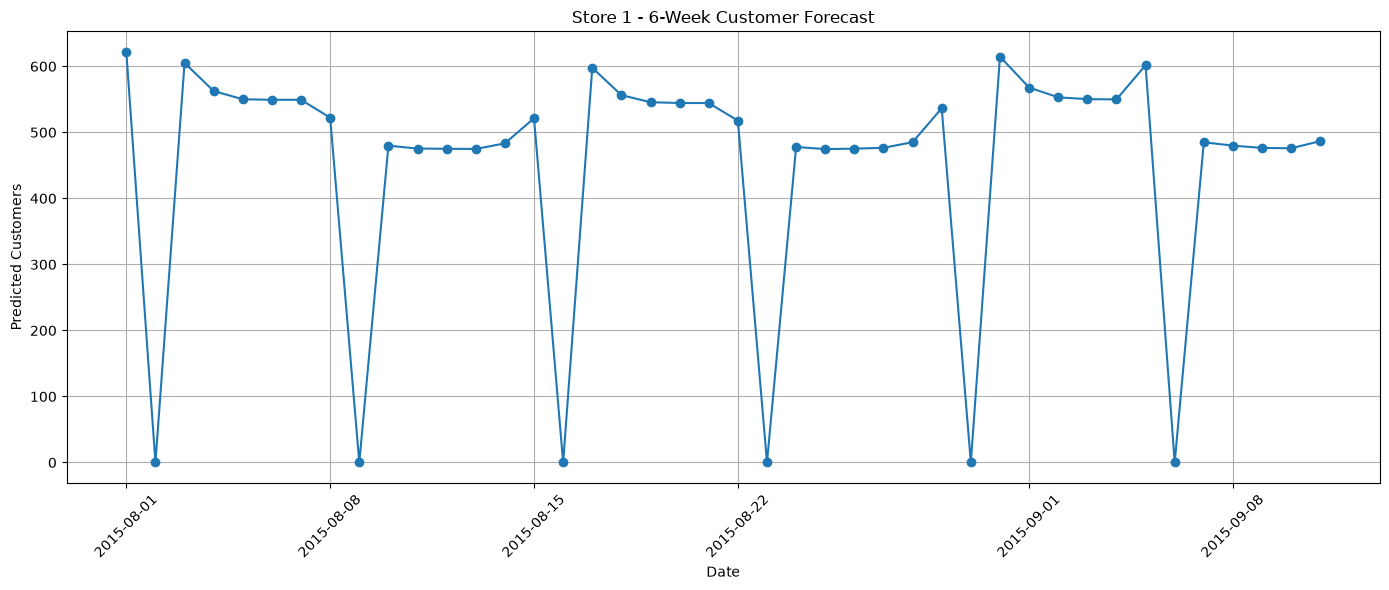

In [321]:
plt.figure(figsize=(14, 6))

plt.plot(
    store_1_6week["Date"],
    store_1_6week["PredictedCustomers"],
    marker="o"
)

plt.title("Store 1 - 6-Week Customer Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [322]:
# ==========================================
# STEP 35: SAVE FINAL FORECAST
# ==========================================

forecast_file = "rossmann_final_forecast.csv"

forecast_df.to_csv(
    forecast_file,
    index=False
)

print("Final forecast CSV saved successfully ✅")
print("File:", forecast_file)
print("Rows:", len(forecast_df))

Final forecast CSV saved successfully ✅
File: rossmann_final_forecast.csv
Rows: 41088


In [323]:
store_1_file = "store_1_6week_forecast.csv"

store_1_6week.to_csv(
    store_1_file,
    index=False
)

print("Store 1 6-week forecast saved ✅")
print("File:", store_1_file)

Store 1 6-week forecast saved ✅
File: store_1_6week_forecast.csv


In [324]:
import os
import glob

print("Current folder:")
print(os.getcwd())

print("\nModels folder:")
print(os.listdir("models"))

print("\nCSV files:")
print(glob.glob("*.csv"))

Current folder:
C:\Users\Anish kumar tiwari\anaconda3\Scripts

Models folder:
['rossmann_customer_rf_01-10-2026-15-40-57.pkl', 'rossmann_feature_lstm.keras', 'rossmann_feature_scaler.pkl']

CSV files:
['engagement_clusters.csv', 'engagement_clusters_4.csv', 'experience_clusters.csv', 'final_satisfaction_table.csv', 'model_tracking_report.csv', 'rossmann_final_forecast.csv', 'satisfaction_clusters.csv', 'store_1_6week_forecast.csv', 'top_10_duration.csv', 'top_10_handsets.csv', 'top_10_rtt.csv', 'top_10_satisfied.csv', 'top_10_sessions.csv', 'top_10_tcp.csv', 'top_10_throughput.csv', 'top_10_traffic.csv', 'top_3_manufacturers.csv', 'user_engagement.csv', 'user_experience.csv']


In [325]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.58.0


In [326]:
import os

matches = []

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.startswith("rossmann_rf_") and file.endswith(".pkl"):
            matches.append(os.path.join(root, file))

print("Sales model files found:")

if matches:
    for file in matches:
        print(file)
else:
    print("Sales Random Forest model not found ❌")

Sales model files found:
C:\Users\Anish kumar tiwari\anaconda3\Scripts\rossmann_rf_01-10-2026-14-31-51.pkl


In [327]:
import shutil
import os

sales_model_source = r"C:\Users\Anish kumar tiwari\anaconda3\Scripts\rossmann_rf_01-10-2026-14-31-51.pkl"

sales_model_destination = os.path.join(
    os.getcwd(),
    "models",
    "rossmann_rf_01-10-2026-14-31-51.pkl"
)

shutil.copy2(
    sales_model_source,
    sales_model_destination
)

print("Sales model copied successfully ✅")
print("Destination:")
print(sales_model_destination)

Sales model copied successfully ✅
Destination:
C:\Users\Anish kumar tiwari\anaconda3\Scripts\models\rossmann_rf_01-10-2026-14-31-51.pkl


In [328]:
import os

print("FINAL MODELS")
print("=" * 40)

for file in os.listdir("models"):
    print("✅", file)

FINAL MODELS
✅ rossmann_customer_rf_01-10-2026-15-40-57.pkl
✅ rossmann_feature_lstm.keras
✅ rossmann_feature_scaler.pkl
✅ rossmann_rf_01-10-2026-14-31-51.pkl


In [342]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="Rossmann Sales Forecasting",
    page_icon="📊",
    layout="wide"
)

# ==========================================
# MODEL PATHS
# ==========================================

SALES_MODEL_PATH = "models/rossmann_rf_01-10-2026-14-31-51.pkl"

CUSTOMER_MODEL_PATH = "models/rossmann_customer_rf_01-10-2026-15-40-57.pkl"

# ==========================================
# LOAD MODELS
# ==========================================

@st.cache_resource
def load_models():

    sales_model = joblib.load(SALES_MODEL_PATH)

    customer_model = joblib.load(CUSTOMER_MODEL_PATH)

    return sales_model, customer_model


sales_model, customer_model = load_models()


# ==========================================
# TITLE
# ==========================================

st.title("📊 Rossmann Sales Forecasting")

st.markdown(
    "### Sales & Customer Prediction Dashboard"
)

st.write(
    "Upload future store data to generate real sales "
    "and customer predictions using trained machine learning models."
)

st.divider()


# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.header("⚙️ Forecast Settings")

uploaded_file = st.sidebar.file_uploader(
    "Upload CSV file",
    type=["csv"]
)


# ==========================================
# CSV UPLOAD
# ==========================================

if uploaded_file is not None:

    data = pd.read_csv(uploaded_file)
data.columns = (
    data.columns
    .astype(str)
    .str.strip()
    .str.replace("\ufeff", "", regex=False)
)

st.write("Detected columns:", data.columns.tolist())

st.success("CSV uploaded successfully ✅")

st.subheader("📄 Uploaded Data")

    st.dataframe(
        data.head(10),
        use_container_width=True
    )

    st.write(
        "Rows:",
        len(data),
        "| Columns:",
        len(data.columns)
    )

else:

    st.info(
        "Please upload a CSV file containing future store data."
    )

    st.stop()

import os

print("app.py exists:", os.path.exists("app.py"))

if os.path.exists("app.py"):
    print("app.py created successfully ✅")

Overwriting app.py


In [349]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import plotly.express as px


# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Rossmann Forecast AI",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)


# =========================================================
# PREMIUM DARK UI
# =========================================================

st.markdown("""
<style>

#MainMenu {
    visibility: hidden;
}

header {
    visibility: hidden;
}

footer {
    visibility: hidden;
}

.stApp {
    background:
        radial-gradient(
            circle at 10% 10%,
            rgba(124, 58, 237, 0.18),
            transparent 30%
        ),
        radial-gradient(
            circle at 90% 10%,
            rgba(14, 165, 233, 0.15),
            transparent 30%
        ),
        #070b14;

    color: #f8fafc;
}

.block-container {
    max-width: 1450px;
    padding-top: 2rem;
    padding-bottom: 3rem;
}


/* ================= SIDEBAR ================= */

section[data-testid="stSidebar"] {

    background:
        linear-gradient(
            180deg,
            #0b1020 0%,
            #080c16 100%
        );

    border-right:
        1px solid rgba(255,255,255,0.08);
}

section[data-testid="stSidebar"] * {
    color: #e5e7eb;
}


/* ================= HERO ================= */

.hero {

    padding: 32px;

    border-radius: 25px;

    background:
        linear-gradient(
            135deg,
            rgba(124,58,237,0.35),
            rgba(14,165,233,0.20)
        );

    border:
        1px solid rgba(255,255,255,0.10);

    box-shadow:
        0 20px 70px rgba(0,0,0,0.40);

    margin-bottom: 25px;
}

.hero-title {

    font-size: 42px;

    font-weight: 800;

    color: white;

    margin-bottom: 8px;
}

.hero-subtitle {

    color: #b7c1d4;

    font-size: 17px;
}

.status {

    display: inline-block;

    padding: 8px 15px;

    border-radius: 30px;

    background:
        rgba(34,197,94,0.12);

    border:
        1px solid rgba(34,197,94,0.30);

    color: #4ade80;

    font-size: 13px;

    font-weight: 700;
}


/* ================= KPI ================= */

.kpi {

    padding: 23px;

    border-radius: 20px;

    background:
        rgba(15,23,42,0.78);

    border:
        1px solid rgba(255,255,255,0.08);

    box-shadow:
        0 12px 35px rgba(0,0,0,0.25);

    min-height: 135px;
}

.kpi-icon {

    font-size: 26px;

    margin-bottom: 8px;
}

.kpi-label {

    color: #94a3b8;

    font-size: 14px;

    margin-bottom: 8px;
}

.kpi-value {

    color: white;

    font-size: 28px;

    font-weight: 800;
}


/* ================= SECTION ================= */

.section-title {

    font-size: 23px;

    font-weight: 750;

    color: white;

    margin-top: 30px;

    margin-bottom: 15px;
}


/* ================= INFO CARD ================= */

.info-card {

    padding: 20px;

    border-radius: 18px;

    background:
        rgba(15,23,42,0.72);

    border:
        1px solid rgba(255,255,255,0.08);

    box-shadow:
        0 10px 30px rgba(0,0,0,0.20);
}


/* ================= DOWNLOAD ================= */

.stDownloadButton button {

    width: 100%;

    border-radius: 12px;

    font-weight: 700;
}


/* ================= FILE UPLOADER ================= */

[data-testid="stFileUploader"] {

    background:
        rgba(15,23,42,0.45);

    border-radius: 16px;
}


/* ================= DATAFRAME ================= */

[data-testid="stDataFrame"] {

    border-radius: 15px;

    overflow: hidden;
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# MODEL PATHS
# =========================================================

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

SALES_MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "rossmann_rf_01-10-2026-14-31-51.pkl"
)

CUSTOMER_MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "rossmann_customer_rf_01-10-2026-15-40-57.pkl"
)

STORE_FILE = os.path.join(
    BASE_DIR,
    "store.csv"
)


# =========================================================
# MODEL LOADING
# =========================================================

@st.cache_resource
def load_models():

    sales_model = joblib.load(
        SALES_MODEL_PATH
    )

    customer_model = joblib.load(
        CUSTOMER_MODEL_PATH
    )

    return sales_model, customer_model


# =========================================================
# LOAD MODELS
# =========================================================

try:

    sales_model, customer_model = load_models()

    models_loaded = True

except Exception as e:

    models_loaded = False

    model_error = str(e)


# =========================================================
# FEATURE LISTS
# =========================================================

numeric_features = [

    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "SchoolHoliday",

    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",

    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",

    "Year",
    "Month",
    "Day",
    "WeekOfYear",

    "IsWeekend",
    "IsHoliday",

    "HolidayBefore",
    "HolidayAfter",

    "CompetitionAgeDays",

    "Promo2Active",

    "DaysSinceCompetitionOpen"
]


categorical_features = [

    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval",
    "MonthPeriod"
]


# =========================================================
# HERO
# =========================================================

st.markdown(
    """
    <div class="hero">

        <div class="hero-title">
            📊 Rossmann Forecast AI
        </div>

        <div class="hero-subtitle">
            Intelligent Sales & Customer Forecasting Dashboard
        </div>

        <br>

        <span class="status">
            ● MACHINE LEARNING MODEL ONLINE
        </span>

    </div>
    """,
    unsafe_allow_html=True
)


# =========================================================
# SIDEBAR
# =========================================================

with st.sidebar:

    st.markdown(
        "## ⚙️ Forecast Center"
    )

    st.write(
        "Upload future store data to generate real predictions."
    )

    uploaded_file = st.file_uploader(
        "📁 Upload CSV",
        type=["csv"]
    )

    st.divider()

    st.markdown(
        "### 🤖 Active Models"
    )

    st.write(
        "🟢 Sales Random Forest"
    )

    st.write(
        "🟢 Customer Random Forest"
    )

    st.write(
        "🟢 Feature LSTM"
    )

    st.divider()

    st.markdown(
        "### 📌 Project"
    )

    st.caption(
        "Rossmann Sales Forecasting"
    )

    st.caption(
        "Python • Pandas • Scikit-learn"
    )

    st.caption(
        "TensorFlow • Streamlit"
    )


# =========================================================
# MODEL ERROR
# =========================================================

if not models_loaded:

    st.error(
        "❌ Model loading failed."
    )

    st.code(
        model_error
    )

    st.stop()


# =========================================================
# NO FILE
# =========================================================

if uploaded_file is None:

    st.markdown(
        """
        <div class="info-card">

        <h2>📁 Upload Your Future Store Data</h2>

        <p>
        Upload a Rossmann-style CSV and the application
        will automatically generate real machine-learning
        predictions.
        </p>

        <br>

        <b>Required columns:</b>

        <br><br>

        <code>
        Store, Date, Open, Promo, StateHoliday, SchoolHoliday
        </code>

        <br><br>

        <b>Output:</b>

        <br>

        📈 Sales Prediction<br>
        👥 Customer Prediction<br>
        📅 6-Week Forecast<br>
        📥 Downloadable CSV

        </div>
        """,
        unsafe_allow_html=True
    )

    st.stop()


# =========================================================
# READ CSV
# =========================================================

try:

    data = pd.read_csv(
        uploaded_file
    )

except Exception as e:

    st.error(
        "❌ Could not read CSV."
    )

    st.code(
        str(e)
    )

    st.stop()


# =========================================================
# CLEAN COLUMN NAMES
# =========================================================

data.columns = (
    data.columns
    .astype(str)
    .str.strip()
    .str.replace(
        "\ufeff",
        "",
        regex=False
    )
)


# =========================================================
# COLUMN ALIAS FIX
# =========================================================

column_aliases = {

    "store": "Store",
    "STORE": "Store",

    "date": "Date",
    "DATE": "Date",

    "open": "Open",
    "OPEN": "Open",

    "promo": "Promo",
    "PROMO": "Promo",

    "stateholiday": "StateHoliday",
    "StateHoliday ": "StateHoliday",

    "schoolholiday": "SchoolHoliday",
    "SchoolHoliday ": "SchoolHoliday",

    "dayofweek": "DayOfWeek",
    "DAYOFWEEK": "DayOfWeek",

    "id": "Id",
    "ID": "Id"
}


data = data.rename(
    columns=column_aliases
)


# =========================================================
# SHOW DETECTED COLUMNS
# =========================================================

with st.expander(
    "🔍 View uploaded CSV information"
):

    st.write(
        "Detected columns:"
    )

    st.write(
        data.columns.tolist()
    )

    st.write(
        "Rows:",
        len(data)
    )


# =========================================================
# REQUIRED COLUMNS
# =========================================================

required_columns = [

    "Store",
    "Date",
    "Open",
    "Promo",
    "StateHoliday",
    "SchoolHoliday"
]


missing_columns = [

    col

    for col in required_columns

    if col not in data.columns
]


if missing_columns:

    st.error(
        "❌ Missing required columns:"
    )

    st.write(
        missing_columns
    )

    st.info(
        "Please upload the Rossmann test.csv file."
    )

    st.stop()


# =========================================================
# DATE
# =========================================================

data["Date"] = pd.to_datetime(
    data["Date"],
    errors="coerce"
)


data = data.dropna(
    subset=["Date"]
)


# =========================================================
# SORT
# =========================================================

data = data.sort_values(
    ["Store", "Date"]
).reset_index(
    drop=True
)


# =========================================================
# LOAD STORE DATA
# =========================================================

if not os.path.exists(
    STORE_FILE
):

    st.error(
        "❌ store.csv not found."
    )

    st.info(
        "Keep store.csv in the same folder as app.py."
    )

    st.stop()


store_data = pd.read_csv(
    STORE_FILE
)


store_columns = [

    "Store",
    "StoreType",
    "Assortment",

    "CompetitionDistance",

    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",

    "Promo2",

    "Promo2SinceWeek",
    "Promo2SinceYear",

    "PromoInterval"
]


store_data = store_data[
    store_columns
]


# =========================================================
# MERGE STORE DATA
# =========================================================

if "StoreType" not in data.columns:

    data = data.merge(
        store_data,
        on="Store",
        how="left"
    )


# =========================================================
# FEATURE ENGINEERING
# =========================================================

data["Year"] = (
    data["Date"].dt.year
)


data["Month"] = (
    data["Date"].dt.month
)


data["Day"] = (
    data["Date"].dt.day
)


data["WeekOfYear"] = (

    data["Date"]
    .dt.isocalendar()
    .week
    .astype(int)

)


data["IsWeekend"] = (

    data["DayOfWeek"]
    .isin([6, 7])
    .astype(int)

)


data["MonthPeriod"] = (

    data["Date"]
    .dt.to_period("M")
    .astype(str)

)


data["IsHoliday"] = (

    data["StateHoliday"]
    .astype(str)
    .ne("0")
    .astype(int)

)


# =========================================================
# HOLIDAY FEATURES
# =========================================================

data["HolidayBefore"] = (

    data
    .groupby("Store")["IsHoliday"]
    .shift(1)
    .fillna(0)
    .astype(int)

)


data["HolidayAfter"] = (

    data
    .groupby("Store")["IsHoliday"]
    .shift(-1)
    .fillna(0)
    .astype(int)

)


# =========================================================
# COMPETITION DATE
# =========================================================

data["CompetitionOpenDate"] = pd.to_datetime(

    dict(

        year=data[
            "CompetitionOpenSinceYear"
        ],

        month=data[
            "CompetitionOpenSinceMonth"
        ],

        day=1

    ),

    errors="coerce"

)


# =========================================================
# COMPETITION AGE
# =========================================================

data["CompetitionAgeDays"] = (

    data["Date"]
    -
    data["CompetitionOpenDate"]

).dt.days


data["CompetitionAgeDays"] = (

    data["CompetitionAgeDays"]
    .clip(lower=0)
    .fillna(0)

)


# =========================================================
# PROMO2
# =========================================================

data["Promo2Active"] = (

    data["Promo2"]
    .fillna(0)
    .eq(1)
    .astype(int)

)


data["DaysSinceCompetitionOpen"] = (

    data["CompetitionAgeDays"]

)


# =========================================================
# MODEL INPUT
# =========================================================

sales_columns = [

    col

    for col in (
        numeric_features
        +
        categorical_features
    )

    if col in data.columns

]


customer_columns = sales_columns.copy()


X_sales = data[
    sales_columns
].copy()


X_customer = data[
    customer_columns
].copy()


# =========================================================
# PREDICTION
# =========================================================

try:

    sales_prediction = (

        sales_model
        .predict(X_sales)

    )


    customer_prediction = (

        customer_model
        .predict(X_customer)

    )


except Exception as e:

    st.error(
        "❌ Prediction failed."
    )

    st.code(
        str(e)
    )

    st.stop()


# =========================================================
# CLOSED STORE BUSINESS RULE
# =========================================================

closed_mask = (

    data["Open"]
    .fillna(0)
    .eq(0)
    .values

)


sales_prediction[
    closed_mask
] = 0


customer_prediction[
    closed_mask
] = 0


# =========================================================
# REMOVE NEGATIVE VALUES
# =========================================================

sales_prediction = np.maximum(
    sales_prediction,
    0
)


customer_prediction = np.maximum(
    customer_prediction,
    0
)


# =========================================================
# ADD PREDICTIONS
# =========================================================

data["PredictedSales"] = (
    sales_prediction
)


data["PredictedCustomers"] = (
    customer_prediction
)


# =========================================================
# STORE SELECTOR
# =========================================================

stores = sorted(
    data["Store"]
    .dropna()
    .unique()
)


selected_store = st.sidebar.selectbox(
    "🏪 Select Store",
    stores
)


store_forecast = data[
    data["Store"] == selected_store
].copy()


store_forecast = store_forecast.sort_values(
    "Date"
)


# =========================================================
# 6 WEEK FORECAST
# =========================================================

store_6week = (

    store_forecast
    .head(42)
    .copy()

)


# =========================================================
# KPI CALCULATIONS
# =========================================================

total_sales = (

    store_6week[
        "PredictedSales"
    ]
    .sum()

)


total_customers = (

    store_6week[
        "PredictedCustomers"
    ]
    .sum()

)


open_days = (

    store_6week[
        "Open"
    ]
    .fillna(0)
    .eq(1)
    .sum()

)


promo_days = (

    store_6week[
        "Promo"
    ]
    .fillna(0)
    .eq(1)
    .sum()

)


# =========================================================
# KPI CARDS
# =========================================================

col1, col2, col3, col4 = st.columns(4)


with col1:

    st.markdown(
        f"""
        <div class="kpi">

        <div class="kpi-icon">
        💰
        </div>

        <div class="kpi-label">
        6-Week Predicted Sales
        </div>

        <div class="kpi-value">
        ₹{total_sales:,.0f}
        </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with col2:

    st.markdown(
        f"""
        <div class="kpi">

        <div class="kpi-icon">
        👥
        </div>

        <div class="kpi-label">
        Predicted Customers
        </div>

        <div class="kpi-value">
        {total_customers:,.0f}
        </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with col3:

    st.markdown(
        f"""
        <div class="kpi">

        <div class="kpi-icon">
        📅
        </div>

        <div class="kpi-label">
        Open Days
        </div>

        <div class="kpi-value">
        {open_days}
        </div>

        </div>
        """,
        unsafe_allow_html=True
    )


with col4:

    st.markdown(
        f"""
        <div class="kpi">

        <div class="kpi-icon">
        🎯
        </div>

        <div class="kpi-label">
        Promo Days
        </div>

        <div class="kpi-value">
        {promo_days}
        </div>

        </div>
        """,
        unsafe_allow_html=True
    )


# =========================================================
# STORE OVERVIEW
# =========================================================

st.markdown(
    '<div class="section-title">🏪 Store Overview</div>',
    unsafe_allow_html=True
)


info1, info2, info3 = st.columns(3)


store_type = (

    store_forecast[
        "StoreType"
    ]
    .iloc[0]

)


assortment = (

    store_forecast[
        "Assortment"
    ]
    .iloc[0]

)


competition_distance = (

    store_forecast[
        "CompetitionDistance"
    ]
    .iloc[0]

)


with info1:

    st.markdown(
        f"""
        <div class="info-card">

        <b>Store</b>

        <br><br>

        <span style="
            font-size:25px;
            font-weight:800;
        ">

        #{selected_store}

        </span>

        </div>
        """,
        unsafe_allow_html=True
    )


with info2:

    st.markdown(
        f"""
        <div class="info-card">

        <b>Store Type</b>

        <br><br>

        <span style="
            font-size:25px;
            font-weight:800;
        ">

        {store_type}

        </span>

        <br>

        Assortment: {assortment}

        </div>
        """,
        unsafe_allow_html=True
    )


with info3:

    if pd.isna(
        competition_distance
    ):

        competition_text = "N/A"

    else:

        competition_text = (
            f"{competition_distance:,.0f} m"
        )


    st.markdown(
        f"""
        <div class="info-card">

        <b>Competition Distance</b>

        <br><br>

        <span style="
            font-size:25px;
            font-weight:800;
        ">

        {competition_text}

        </span>

        </div>
        """,
        unsafe_allow_html=True
    )


# =========================================================
# SALES FORECAST
# =========================================================

st.markdown(
    '<div class="section-title">📈 6-Week Sales Forecast</div>',
    unsafe_allow_html=True
)


fig_sales = px.area(

    store_6week,

    x="Date",

    y="PredictedSales",

    title=(
        f"Store {selected_store} — "
        "Predicted Sales"
    ),

    template="plotly_dark"

)


fig_sales.update_layout(

    height=450,

    margin=dict(
        l=20,
        r=20,
        t=60,
        b=20
    ),

    hovermode="x unified"

)


st.plotly_chart(

    fig_sales,

    use_container_width=True

)


# =========================================================
# CUSTOMER FORECAST
# =========================================================

st.markdown(
    '<div class="section-title">👥 6-Week Customer Forecast</div>',
    unsafe_allow_html=True
)


fig_customers = px.line(

    store_6week,

    x="Date",

    y="PredictedCustomers",

    markers=True,

    title=(
        f"Store {selected_store} — "
        "Predicted Customers"
    ),

    template="plotly_dark"

)


fig_customers.update_layout(

    height=420,

    margin=dict(
        l=20,
        r=20,
        t=60,
        b=20
    ),

    hovermode="x unified"

)


st.plotly_chart(

    fig_customers,

    use_container_width=True

)


# =========================================================
# FORECAST TABLE
# =========================================================

st.markdown(
    '<div class="section-title">📋 Daily Forecast</div>',
    unsafe_allow_html=True
)


display_columns = [

    "Date",
    "DayOfWeek",
    "Open",
    "Promo",
    "PredictedSales",
    "PredictedCustomers"

]


display_data = store_6week[
    display_columns
].copy()


display_data[
    "PredictedSales"
] = (

    display_data[
        "PredictedSales"
    ]
    .round(2)

)


display_data[
    "PredictedCustomers"
] = (

    display_data[
        "PredictedCustomers"
    ]
    .round(2)

)


st.dataframe(

    display_data,

    use_container_width=True,

    hide_index=True

)


# =========================================================
# DOWNLOAD
# =========================================================

download_data = (

    store_6week
    .to_csv(index=False)
    .encode("utf-8")

)


st.download_button(

    label="📥 Download 6-Week Forecast CSV",

    data=download_data,

    file_name=(
        f"store_{selected_store}"
        "_6_week_forecast.csv"
    ),

    mime="text/csv"

)


# =========================================================
# MODEL PERFORMANCE
# =========================================================

st.markdown(
    '<div class="section-title">🤖 Model Performance</div>',
    unsafe_allow_html=True
)


m1, m2, m3 = st.columns(3)


with m1:

    st.markdown(
        """
        <div class="info-card">

        <b>🌲 Sales Random Forest</b>

        <br><br>

        MAE:
        <b>809.63</b>

        <br>

        RMSE:
        <b>1256.89</b>

        </div>
        """,
        unsafe_allow_html=True
    )


with m2:

    st.markdown(
        """
        <div class="info-card">

        <b>👥 Customer Random Forest</b>

        <br><br>

        MAE:
        <b>56.45</b>

        <br>

        RMSE:
        <b>86.79</b>

        </div>
        """,
        unsafe_allow_html=True
    )


with m3:

    st.markdown(
        """
        <div class="info-card">

        <b>🧠 Feature LSTM</b>

        <br><br>

        MAE:
        <b>453.62</b>

        <br>

        RMSE:
        <b>762.53</b>

        </div>
        """,
        unsafe_allow_html=True
    )


# =========================================================
# FOOTER
# =========================================================

st.divider()


st.markdown(
    """
    <div style="
        text-align:center;
        color:#64748b;
        padding:20px;
        font-size:14px;
    ">

    <b>Rossmann Forecast AI</b>

    <br>

    Sales Forecasting • Customer Forecasting • Machine Learning

    <br><br>

    Python • Pandas • Scikit-learn • TensorFlow • Streamlit

    </div>
    """,
    unsafe_allow_html=True
)

Overwriting app.py


OSError: [Errno 22] Invalid argument: 'app.py'